In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import make_pipeline,Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix,mean_absolute_error,mean_squared_error,r2_score

In [17]:
from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.preprocessing import OneHotEncoder,StandardScaler,OrdinalEncoder,FunctionTransformer

In [18]:
from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [19]:
import sklearn
sklearn.set_config(transform_output="pandas")

In [20]:
# 讀取資料
df = pd.read_csv("train.csv")
df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [21]:
# 欄位太多會省略，要求數字類型表格要全數呈現
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows',None)
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [22]:
# 調查缺失值欄位與數量
null_data = df.isnull().sum()
null_columns = null_data[null_data > 0].sort_values( ascending = True)
print(null_columns)

Electrical         1
MasVnrArea         8
BsmtCond          37
BsmtFinType1      37
BsmtQual          37
BsmtExposure      38
BsmtFinType2      38
GarageType        81
GarageQual        81
GarageFinish      81
GarageCond        81
GarageYrBlt       81
LotFrontage      259
FireplaceQu      690
MasVnrType       872
Fence           1179
Alley           1369
MiscFeature     1406
PoolQC          1453
dtype: int64


In [23]:
# 基本健檢，查看欄位型態與數量
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

<Axes: xlabel='SalePrice', ylabel='Count'>

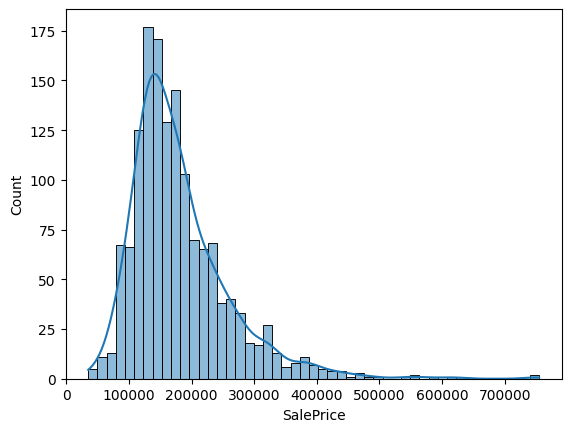

In [24]:
# 房屋的價格屬於右偏分布
sns.histplot(df['SalePrice'], kde=True)

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

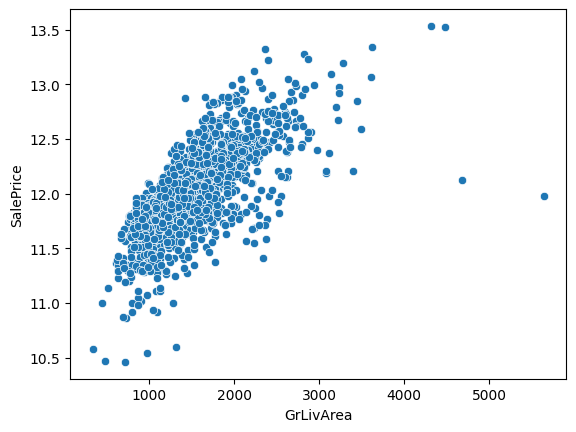

In [25]:
# 房屋的價格屬於右偏分布
sns.scatterplot(y = np.log1p(df['SalePrice']),x = df['GrLivArea'])

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

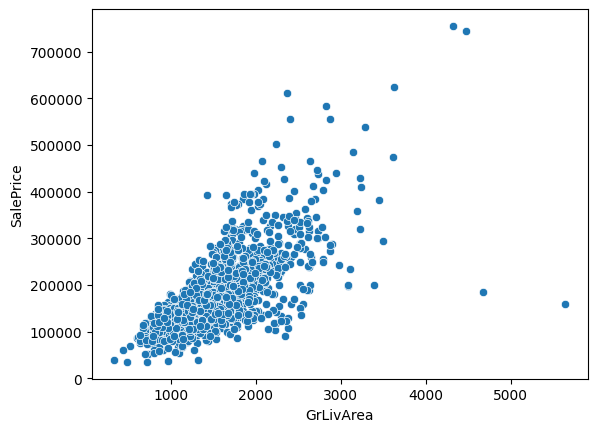

In [26]:
sns.scatterplot(y = df['SalePrice'],x = df['GrLivArea'])

<Axes: xlabel='GrLivArea', ylabel='Count'>

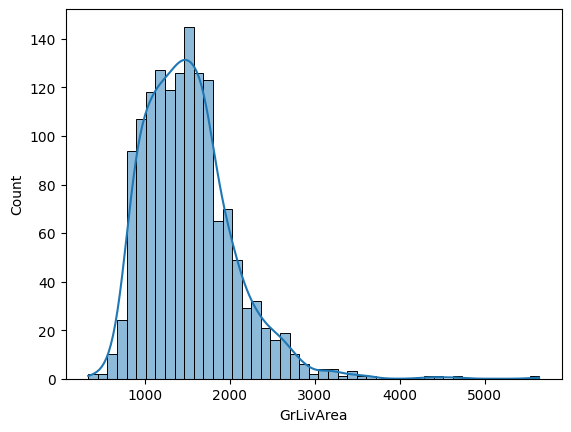

In [27]:
sns.histplot(df['GrLivArea'], kde=True)

### 資料切割

In [28]:
df_raw_01 = df.copy()
X = df_raw_01[df_raw_01.columns[:-1]]
X.head()
Y = df_raw_01['SalePrice']
Y.head()
X_Trainee,x_test,Y_Trainee,y_test = train_test_split(X,Y,test_size=0.2,random_state=42)
X_Train,X_Val,Y_Train,y_Val = train_test_split(X_Trainee,Y_Trainee,test_size=0.18,random_state=42)

print("建模資料準備完成！")
print(f"X_Trainee shape 傳統線性用的 train : {X_Trainee.shape}")
print(f"X_Train shape 有早停法用的 train : {X_Train.shape}")
print(f"x_test shape 全模型衡量指標用的測試: {x_test.shape}")
print(f"X_Val shape 早停法用的: {X_Val.shape}")

建模資料準備完成！
X_Trainee shape 傳統線性用的 train : (1168, 80)
X_Train shape 有早停法用的 train : (957, 80)
x_test shape 全模型衡量指標用的測試: (292, 80)
X_Val shape 早停法用的: (211, 80)


### 篩選相關係數高之欄位
##### 目的
從初步資料健檢發現欄位眾多，筆數眾多，不同欄位的缺失資料也不一。若要每個欄位的都深究其定義、缺失做法，將會花費大量時間。因此先挑出相關係數較高的欄位，作為日後資料清洗之重點。
##### 步驟
1. 透過 Target Encoding 將文字類型要轉換成數值
2. 計算 Correlation
3. 篩選相關係數高於 0.5 的欄位名稱
4. 找出數值類型欄位的離峰值、異常值 <br>
    4-1. 畫箱型圖<br>
    4-2. 散佈圖圖

In [29]:
# 先將文字資料轉成平均數，跟原始讀進來的資料做區分。
dfForHeatMap = pd.concat([X_Train,Y_Train], axis=1)

In [30]:
# 引用target encoding 方式轉換
# 發現 Colab 沒有安裝，所以要先下 pip 裝入
# !pip install category_encoders
import category_encoders as ce

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 940.2 kB/s eta 0:00:00


In [31]:
# 挑出文字資料的欄位
heatmapcolumns_objects = dfForHeatMap.select_dtypes(include=["object"]).columns

TargetEncoder = ce.TargetEncoder(cols=heatmapcolumns_objects)
dfForHeatMap = TargetEncoder.fit_transform(dfForHeatMap,dfForHeatMap['SalePrice'])


In [32]:
# 粗略篩選，透過相關係數影響先挑出部分欄位

corr_matrix = dfForHeatMap.corr(numeric_only=True)
print("房價相關超過 0.5：")
corr_Over5 = corr_matrix['SalePrice'][lambda x: x >0.5].sort_values(ascending = False)
print(corr_Over5)

房價相關超過 0.5：
SalePrice       1.000000
OverallQual     0.778336
Neighborhood    0.694769
GrLivArea       0.684013
BsmtQual        0.682417
KitchenQual     0.666473
ExterQual       0.659687
GarageCars      0.634446
GarageArea      0.610714
TotalBsmtSF     0.591845
1stFlrSF        0.584809
FullBath        0.555535
GarageFinish    0.539595
FireplaceQu     0.515883
TotRmsAbvGrd    0.513392
YearBuilt       0.510614
Name: SalePrice, dtype: float64


In [33]:
# 查看負相關的是哪些指標
corr_neg = corr_matrix['SalePrice'][lambda x: x < 0 ][:-1].sort_values(ascending = False)
corr_neg

,SalePrice
Id,-0.001076
BsmtHalfBath,-0.050469
MSSubClass,-0.083881
OverallCond,-0.094995
EnclosedPorch,-0.131990
KitchenAbvGr,-0.134445


In [34]:
# 這串跑出來是 Series 類型，先將其轉成一個 df
corr_Over5_df = corr_Over5.to_frame().reset_index().rename(columns={'SalePrice':'SalePrice_Corr','index':'T_columns'})

In [35]:
# 做一個資料類型總表的比對，比對相關係數與資料類型
corr_Over5_df['dtype'] = 'float'
corr_Over5_df.loc[corr_Over5_df['T_columns'].isin(heatmapcolumns_objects.tolist()),'dtype'] = 'object'
corr_Over5_df.sort_values(by='SalePrice_Corr',ascending = False,inplace=True)
corr_Over5_df

,T_columns,SalePrice_Corr,dtype
0,SalePrice,1.000000,float
1,OverallQual,0.778336,float
2,Neighborhood,0.694769,object
3,GrLivArea,0.684013,float
4,BsmtQual,0.682417,object
5,KitchenQual,0.666473,object
6,ExterQual,0.659687,object
7,GarageCars,0.634446,float
8,GarageArea,0.610714,float
9,TotalBsmtSF,0.591845,float


In [36]:
corr_Over5_df.groupby('dtype')['T_columns'].count()

,T_columns
dtype,
float,10
object,6


###### 針對數值資料，釐清異常值


In [37]:
corr_Over5_flt = corr_Over5_df[corr_Over5_df['dtype'] =='float' ]['T_columns']

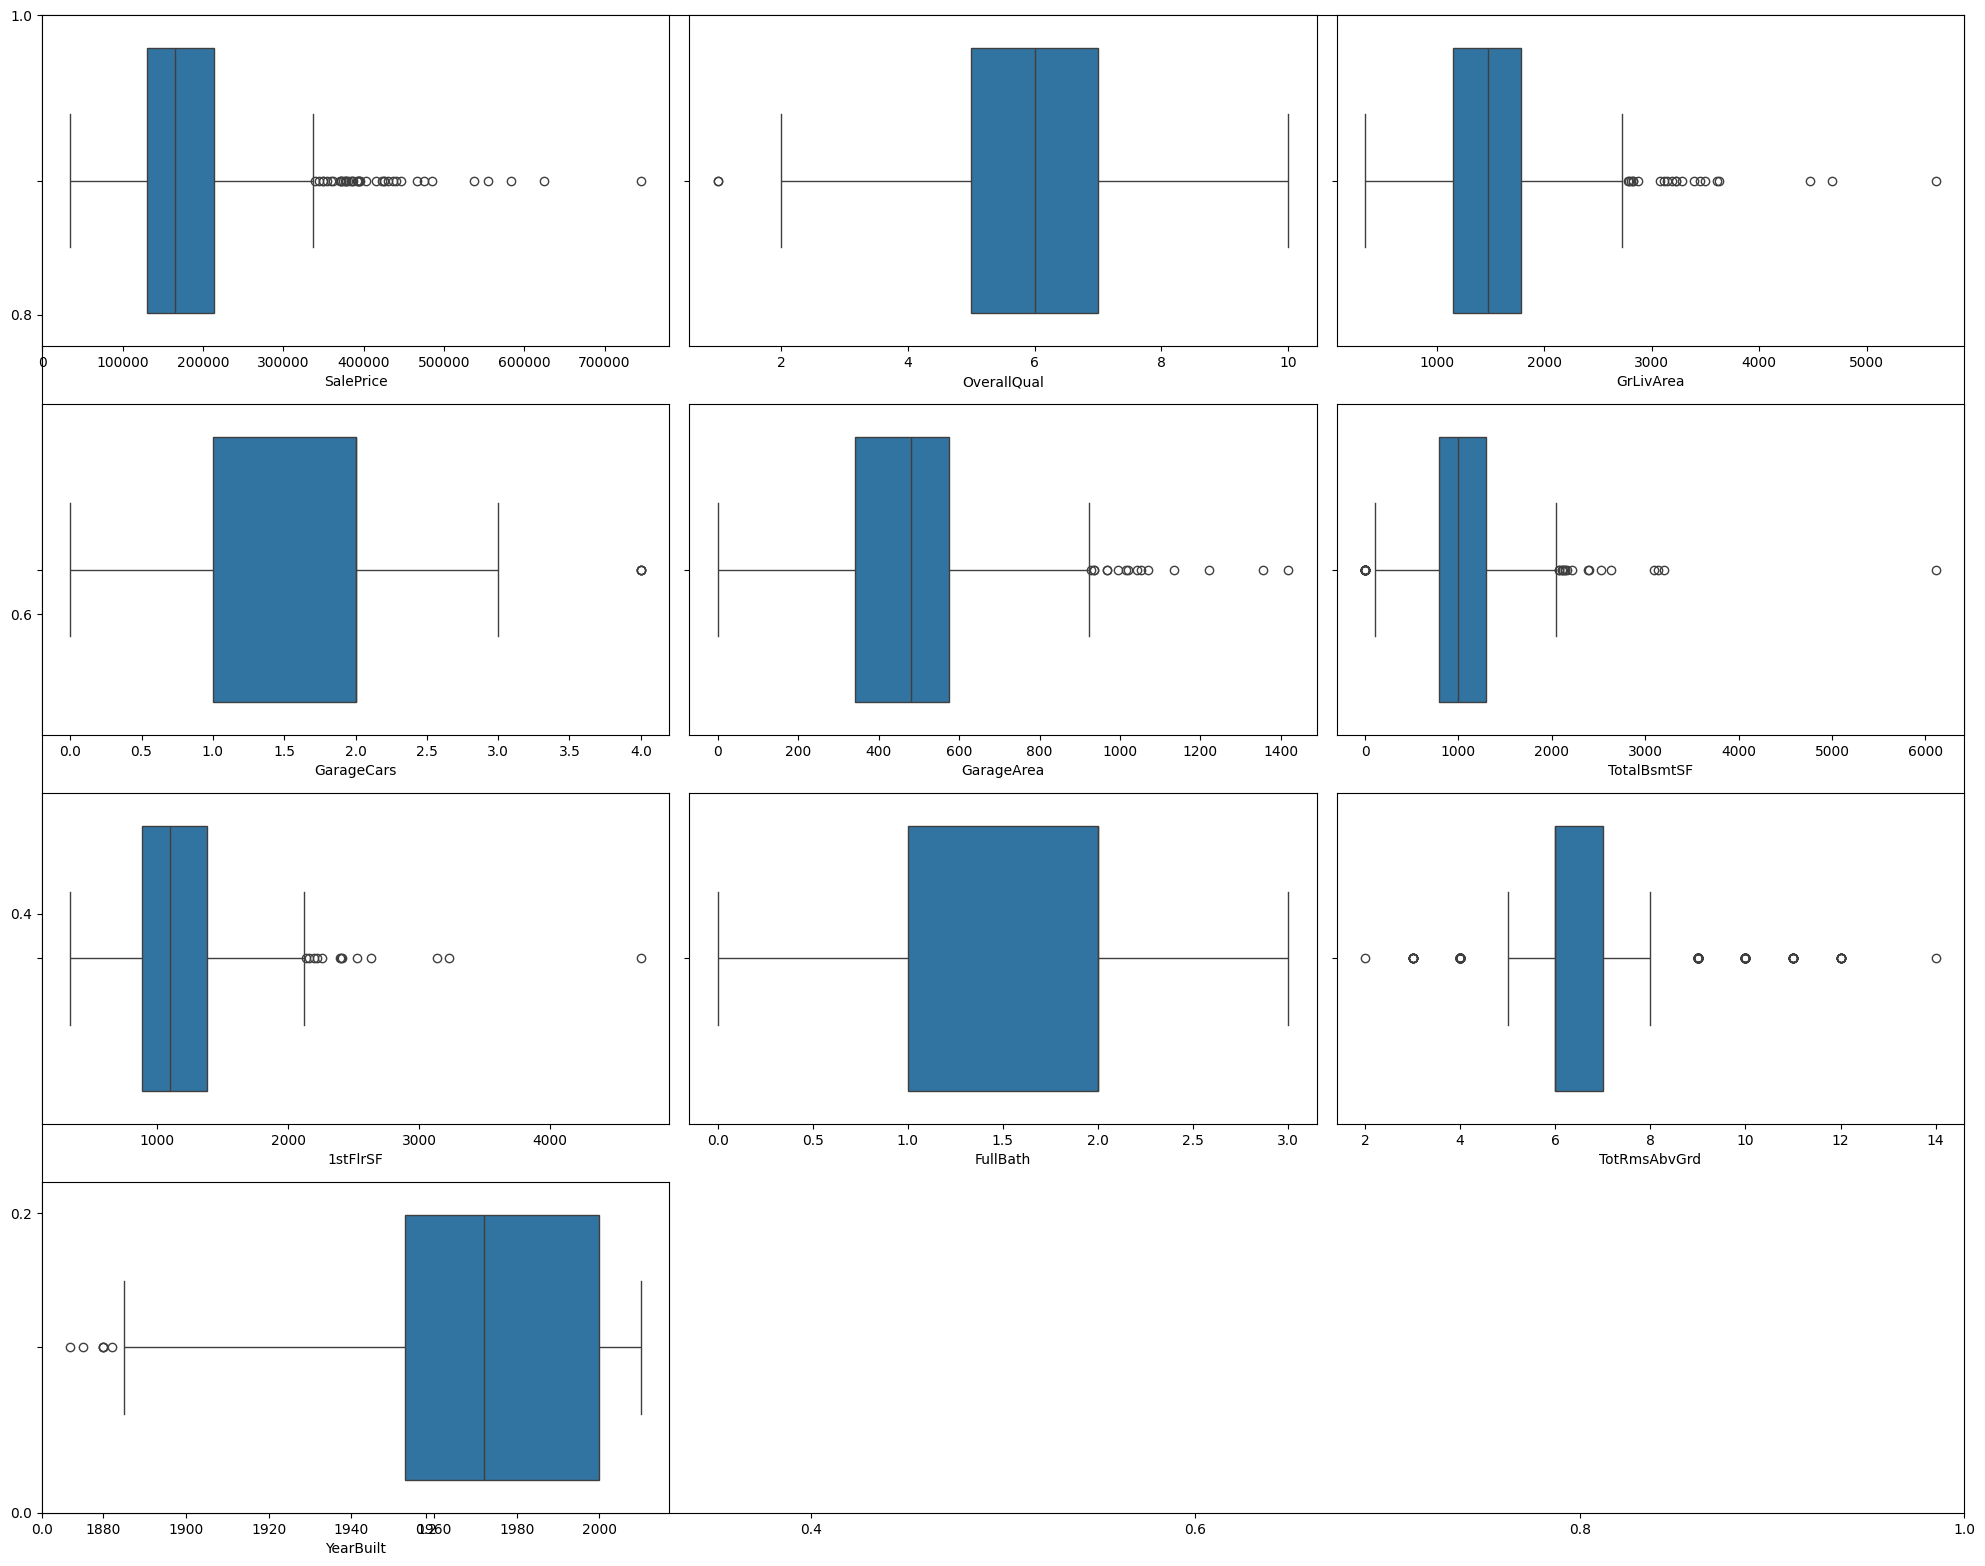

In [38]:
# 數值類型 10 項欄位之箱型圖
plt.subplots(figsize=(20,16))

location =1
for (i) in corr_Over5_flt:
    plt.subplot(4,3,location)
    sns.boxplot(x=dfForHeatMap[i])
    location += 1
plt.tight_layout()

#### 箱型圖解讀
- 從第一行的 SalePrice, GrLivArea 及中段的 GarageArea、 TotalBsmtSF、1stFlrSF 的圖片與離峰值的位置，可判斷這些欄位之資料並非常態分佈，明顯有右偏分布的傾向。
- 實際上右偏之狀況，需後續依據 skewness 數值判斷是否需調整

In [39]:
# 套用 skewnewss 檢查偏態的狀況

skewness = dfForHeatMap[corr_Over5_flt].skew()

print("明顯有偏移的指標：")
print(skewness[np.absolute(skewness) > 1])

print("中等偏移的指標：")
print(skewness[(np.absolute(skewness) < 1) & (np.absolute(skewness) > 0.5)])

# 先撈出確定要做常態處理的指標
mustSkew = skewness[np.absolute(skewness) > 1].index.tolist()
mustSkew

明顯有偏移的指標：
SalePrice      1.879137
GrLivArea      1.577469
TotalBsmtSF    1.985234
1stFlrSF       1.574290
dtype: float64
中等偏移的指標：
TotRmsAbvGrd    0.760450
YearBuilt      -0.604045
dtype: float64


['SalePrice', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF']

#### 偏態分佈
套用偏態分佈的 skewness 的檢查，釐清高相關係數且為數值類型資料的偏移狀況。發現
- 明顯有偏移的指標：
  - SalePrice   ：   1.879137
  - GrLivArea   ：   1.577469
  - TotalBsmtSF ：   1.985234
  - 1stFlrSF    ：   1.574290
- 中等偏移的指標：
  - TotRmsAbvGrd ：    0.760450
  - YearBuilt    ：  -0.604045



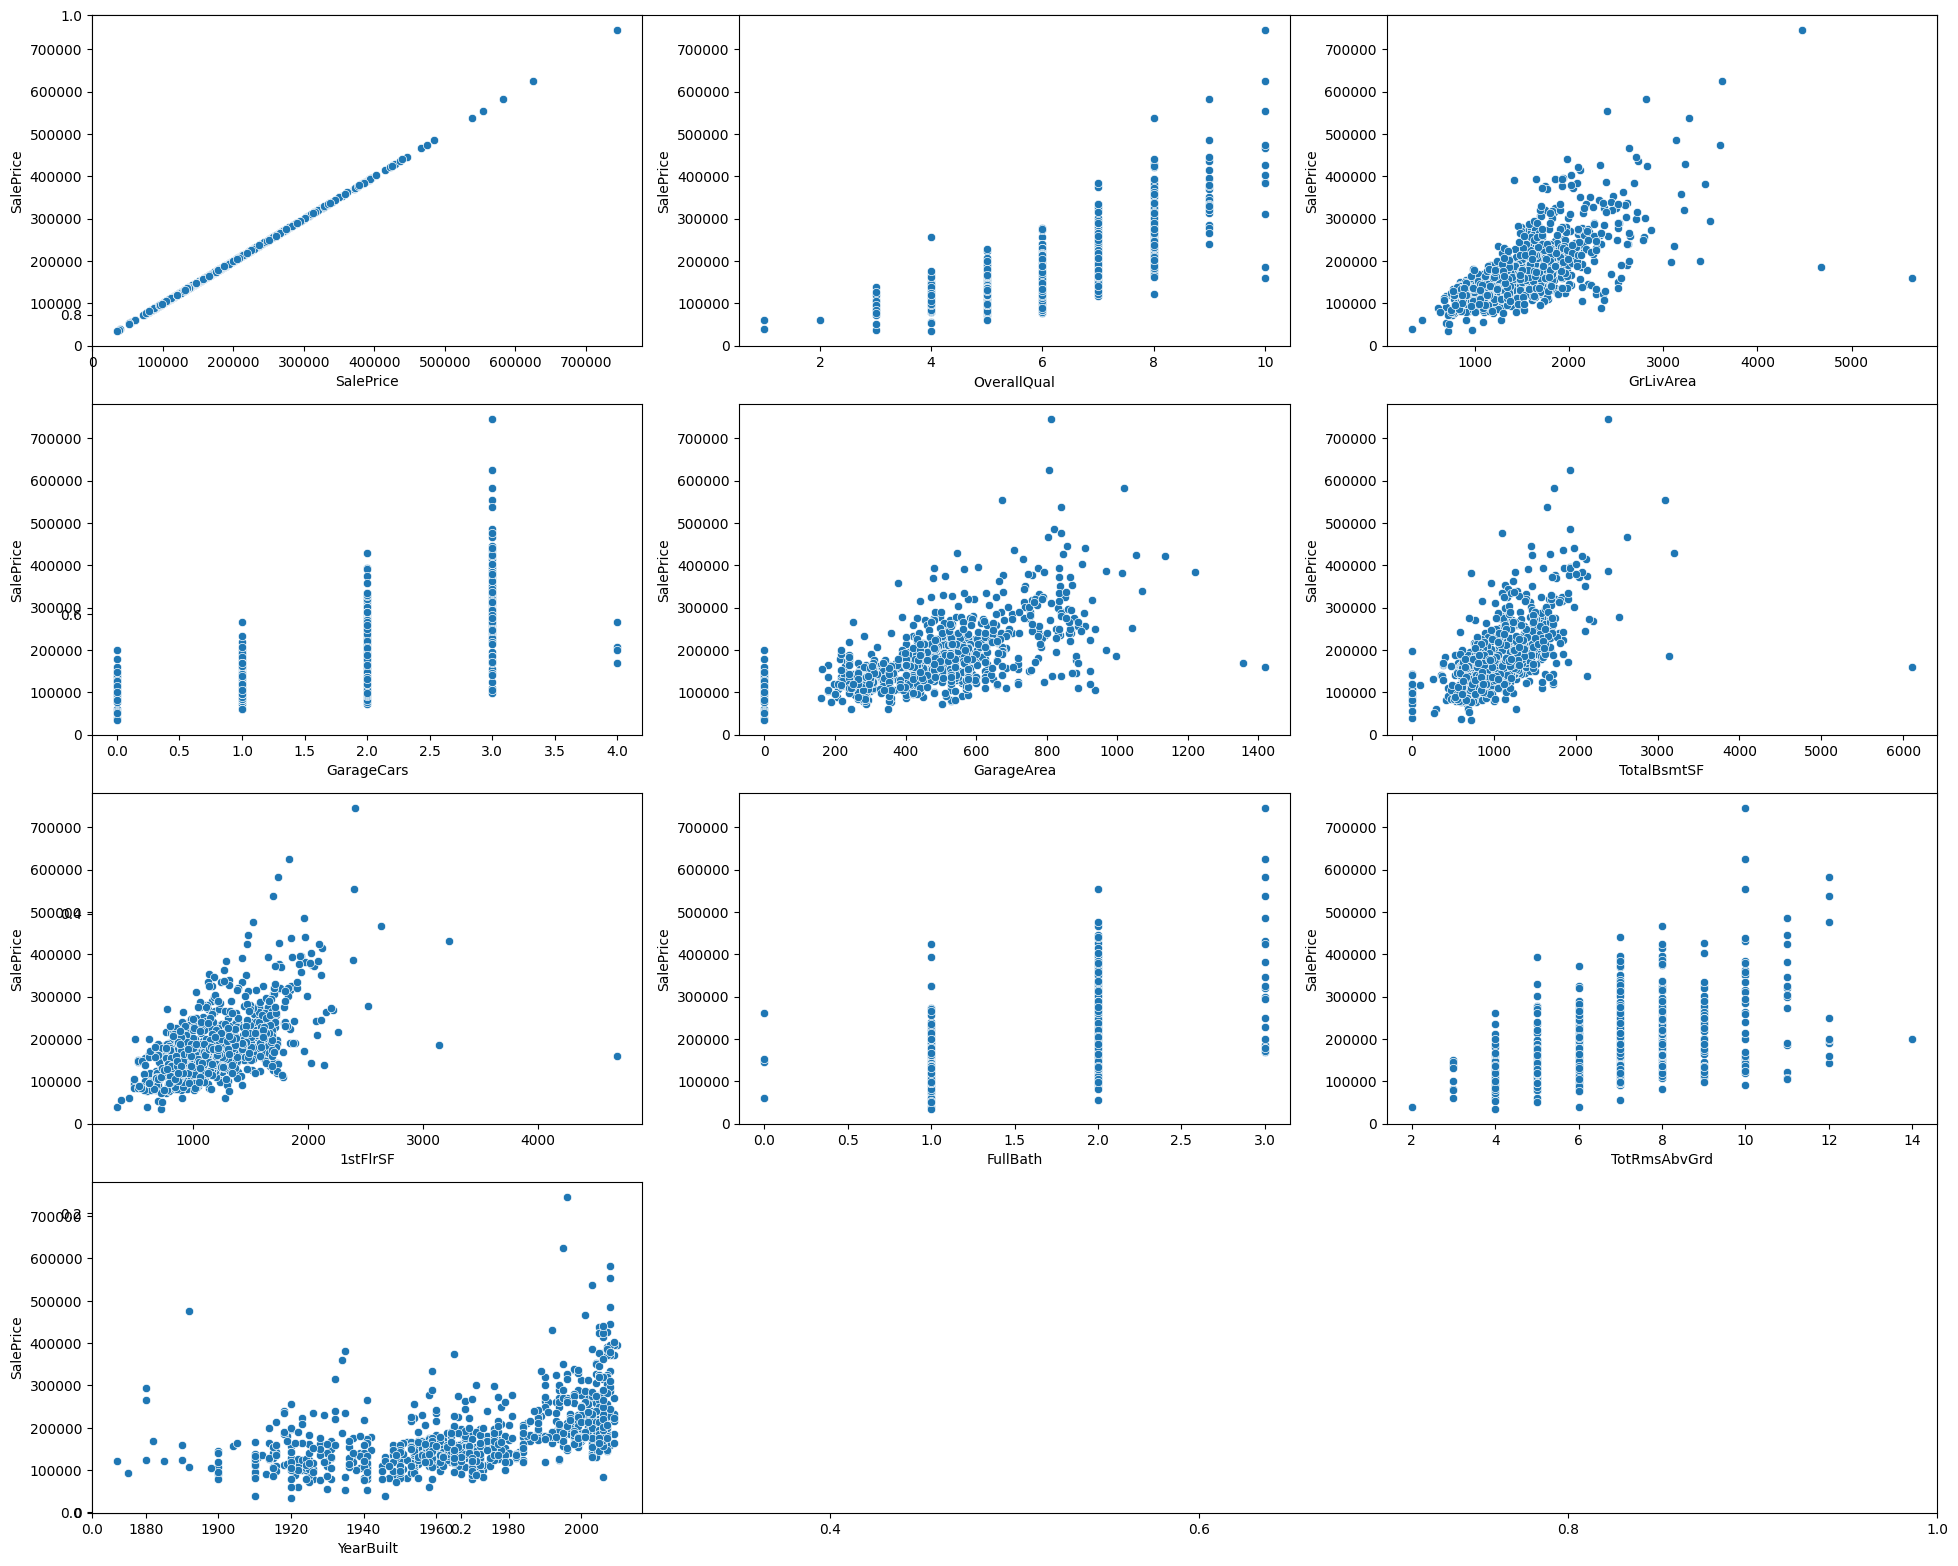

In [40]:
# 散佈圖。找出這 10 項數值與 SalePrice 的散佈關係
plt.subplots(figsize=(20,16))

location =1
for (i) in corr_Over5_flt:
    plt.subplot(4,3,location)
    sns.scatterplot(x=dfForHeatMap[i],y = dfForHeatMap['SalePrice'])
    location += 1
plt.tight_layout()

#### 散佈圖解讀

- 從 GrLivArea ，GarageArea、 TotalBsmtSF、1stFlrSF 這四張圖片，離散與密集程度，可判斷這些欄位之資料具有明顯的離峰值。
- 從相關係數次高者 GrLivArea 的離峰值優先探討。

In [41]:
dfForHeatMap[dfForHeatMap['TotalBsmtSF'] > 6000]
# 撈出來發現這筆資料，就是 GrLivArea > 5000 且 1stFlrSF > 4000  且 GarageArea > 1400  的同筆項目。

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,1299,60,190585.872032,313.0,63887,181170.34696,183701.220112,186964.378191,151908.60585,181206.235356,175286.442587,179744.487293,131843.022461,140349.262484,181301.166667,185343.987516,206934.584718,10,5,2008,2008,217305.50945,178407.396439,186230.94228,180048.323055,258737.23701,796.0,324659.068529,184191.427536,222892.943662,325028.570676,184196.676744,253470.376916,234273.309159,5644,184042.140794,0,466,6110,182250.51606,216019.980973,186694.244944,186775.551487,4692,950,0,5642,2,0,2,1,3,1,327611.835284,12,184094.356335,3,222633.823288,201808.010545,2008.0,236285.111083,2,1418,187077.031142,187565.907216,186477.949657,214,292,0,0,0,480,186313.225051,187041.045692,182010.033769,0,1,2008,274060.212936,274060.212936,160000


In [42]:
dfForHeatMap[(dfForHeatMap['GrLivArea'] > 4000) & (dfForHeatMap['GrLivArea'] < 5000)].sort_values(by='GrLivArea',ascending = False)
# 第二筆異常值。GrLivArea > 4000 但房價僅 184750

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,524,60,190585.872032,130.0,40094,181170.34696,183701.220112,203189.433846,151908.605850,181206.235356,178975.485800,179744.487293,131843.022461,196887.437675,195872.568315,185343.987516,206934.584718,10,5,2007,2008,217305.50945,180573.529224,232291.183918,229420.683523,258737.237010,762.0,324659.068529,184191.427536,222892.943662,325028.570676,184196.676744,253470.376916,234273.309159,2260,184042.140794,0,878,3138,182250.51606,216019.980973,186694.244944,186775.551487,3138,1538,0,4676,1,0,3,1,3,1,327611.835284,11,184094.356335,1,222633.823288,248674.640779,2007.0,236285.111083,3,884,187077.031142,187565.907216,186477.949657,208,406,0,0,0,0,180362.451104,187041.045692,182010.033769,0,10,2007,274060.212936,274060.212936,184750
1182,1183,60,190585.872032,160.0,15623,181170.34696,183701.220112,203189.433846,180082.698962,181206.235356,175286.442587,179744.487293,282297.427613,184694.450670,181301.166667,185343.987516,206934.584718,10,5,1996,1996,217305.50945,180573.529224,149651.685736,202334.690050,158377.757194,0.0,229321.545161,184191.427536,222892.943662,325028.570676,184196.676744,210536.943065,234273.309159,2096,184042.140794,0,300,2396,182250.51606,216019.980973,186694.244944,186775.551487,2411,2065,0,4476,1,0,3,1,4,1,327611.835284,10,184094.356335,2,206796.813866,201808.010545,1996.0,236285.111083,3,813,187077.031142,187565.907216,186477.949657,171,78,0,0,0,555,224969.768003,153499.754003,182010.033769,0,7,2007,174190.853365,156104.836450,745000


In [43]:
# 檢查 GarageArea 的右下角的資料長相
dfForHeatMap[(dfForHeatMap['GarageArea'] > 1200) & (dfForHeatMap['GarageArea'] <= 1400)][['GarageArea','GrLivArea','SalePrice']]

,GarageArea,GrLivArea,SalePrice
1190,1356,1622,168000
825,1220,2084,385000


#### 離峰值
- 根據查詢結果，發現 GrLivArea 的兩筆離峰值，也正好是其他欄位的離峰值項目。故優先刪減這兩筆資料。
- GrLivArea 的相關係數高，若有極端值易影響模型預測結果。
- 其他項目之影響不如 GrLivArea 來得高，故剩下資料予以保留。

In [44]:
# 刪除離峰值 index = 1298, 523

df_dropped = df.drop(index=[1298,523],axis=0)

X_Trainee  = X_Trainee.drop(index=[1298,523],axis=0)
Y_Trainee = Y_Trainee.drop(index=[1298,523],axis=0)
X_Train = X_Train.drop(index=[1298,523],axis=0)
Y_Train = Y_Train.drop(index=[1298,523],axis=0)


print("資料刪除完成！")
print(f"X_Trainee shape 傳統線性用的 train : {X_Trainee.shape}")
print(f"X_Train shape 有早停法用的 train : {X_Train.shape}")
print(f"x_test shape 全模型衡量指標用的測試: {x_test.shape}")
print(f"X_Val shape 早停法用的: {X_Val.shape}")

資料刪除完成！
X_Trainee shape 傳統線性用的 train : (1166, 80)
X_Train shape 有早停法用的 train : (955, 80)
x_test shape 全模型衡量指標用的測試: (292, 80)
X_Val shape 早停法用的: (211, 80)


### 定義缺失值
#### 數值欄位：
無缺失


In [45]:
null_number_COls = corr_Over5_df[(corr_Over5_df['dtype'] == 'float') & (corr_Over5_df['T_columns'].isin(null_columns.index.tolist()))]

null_number_COls
#數值類型資料的高於 0.5 相關係數的指標中，並沒有缺失值。

,T_columns,SalePrice_Corr,dtype


#### 文字欄位：
- BsmtQual:
    - 資料矛盾：無，其他相關 basement 項目也都 NaN
    - 資料缺失：依照手冊定義，NaN 為無地下室，可補 0
    - Encoding: 文字資料有順序之分，如；Ex	Excellent (100+ inches), Po	Poor (<70 inches )。故採取手動 mapping 轉換。
- GarageFinish:
    - 資料矛盾：無，其他相關 Garage 項目也都 NaN
    - 資料缺失：依照手冊定義，NaN 為無地下室，可補 0
    - Encoding: 文字資料有順序之分，如；Fin	Finished,Unf	Unfinished。  故採取手動 mapping 轉換
- FireplaceQu:
    - 資料矛盾：無，其他相關 Fireplace 項目也都 NaN
    - 資料缺失：依照手冊定義，NaN 為無地下室，可補 0
    - Encoding: 文字資料有順序之分，如；Excellent - Exceptional Masonry Fireplace, Po	Poor - Ben Franklin Stove  故採取手動 mapping 轉換
- Neighborhood: 由於分類眾多，也沒有明顯過半的聚集數量，加上與房價高度相關，因此採用 target Encoding。
- ExterQual: 文字資料有順序之分，如；Ex Excellent , Po Poor  故採取手動 mapping 轉換。
- KitchenQual: 文字資料有順序之分，如；Ex Excellent , Po Poor  故採取手動 mapping 轉換。

<br>

綜合以上，Basement 相關欄位、Garage 相關欄位，以及 Fireplace 相關欄位，若有 NaN 者可直接替補為 0。

In [46]:
null_str_Cols = corr_Over5_df[(corr_Over5_df['dtype'] == 'object') & (corr_Over5_df['T_columns'].isin(null_columns.index.tolist()))]
null_str_Cols
X_Trainee[null_str_Cols['T_columns']].isnull().sum()

,0
BsmtQual,28
GarageFinish,64
FireplaceQu,547


### 資料清洗
##### 線性回歸
先根據這 15 項指標跑線性回歸，因此先針對線性模型的方式處理資料缺失值，以文字資料的 encoding

In [47]:
df_15Linear = pd.concat([X_Trainee,Y_Trainee], axis = 1)[corr_Over5_df.T_columns]
X_Trainee[(X_Trainee['FireplaceQu'].isnull()) & (X_Trainee['GarageFinish'].isnull()) & (X_Trainee['BsmtQual'].isnull())]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
705,706,190,RM,70.0,5600,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,IDOTRR,Norm,Norm,2fmCon,2Story,4,5,1930,1950,Hip,CompShg,VinylSd,Wd Shng,NaN,0.0,Fa,Fa,Slab,NaN,NaN,NaN,NaN,0,NaN,0,0,0,GasA,Fa,N,SBrkr,372,720,0,1092,0,0,2,0,3,2,Fa,7,Mod,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,N,0,0,0,0,0,0,NaN,NaN,Othr,3500,7,2010,WD,Normal
39,40,90,RL,65.0,6040,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,Duplex,1Story,4,5,1955,1955,Gable,CompShg,AsbShng,Plywood,NaN,0.0,TA,TA,PConc,NaN,NaN,NaN,NaN,0,NaN,0,0,0,GasA,TA,N,FuseP,1152,0,0,1152,0,0,2,0,2,2,Fa,6,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,N,0,0,0,0,0,0,NaN,NaN,NaN,0,6,2008,WD,AdjLand
533,534,20,RL,50.0,5000,Pave,NaN,Reg,Low,AllPub,Inside,Mod,BrkSide,Norm,Norm,1Fam,1Story,1,3,1946,1950,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,Fa,Fa,Slab,NaN,NaN,NaN,NaN,0,NaN,0,0,0,GasA,Fa,N,FuseF,334,0,0,334,0,0,1,0,1,1,Fa,2,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,N,0,0,0,0,0,0,NaN,NaN,NaN,0,1,2007,WD,Normal
1011,1012,90,RL,75.0,9825,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,Duplex,1Story,5,5,1965,1965,Hip,CompShg,AsphShn,AsphShn,NaN,0.0,TA,TA,CBlock,NaN,NaN,NaN,NaN,0,NaN,0,0,0,GasA,TA,N,SBrkr,1664,0,0,1664,0,0,2,0,4,2,TA,8,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal
1218,1219,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,BrkSide,Norm,Norm,1Fam,1.5Fin,4,5,1947,1950,Gable,CompShg,AsbShng,AsbShng,NaN,0.0,TA,TA,Slab,NaN,NaN,NaN,NaN,0,NaN,0,0,0,GasA,Gd,N,SBrkr,672,240,0,912,0,0,1,0,2,1,TA,3,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,N,0,0,0,0,0,0,NaN,NaN,NaN,0,7,2006,WD,Normal
520,521,190,RL,60.0,10800,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Norm,Norm,2fmCon,2Story,4,7,1900,2000,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,BrkTil,NaN,NaN,NaN,NaN,0,NaN,0,0,0,GasA,TA,N,FuseA,694,600,0,1294,0,0,2,0,3,2,TA,7,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,N,220,114,210,0,0,0,NaN,NaN,NaN,0,8,2008,WD,Normal


In [48]:
fivegrade_mapping = {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1}
GarageFinish_mapping ={'Fin':3,'RFn':2,'Unf':1}
fivegrade_map_list = ['BsmtQual','FireplaceQu','ExterQual','KitchenQual']
# FireplaceQu_mapping =BsmtQual_mapping = ExterQual_mapping = KitchenQual_mapping

In [49]:
# Neighborhood
df_15Linear.groupby('Neighborhood',as_index=False).count()

,Neighborhood,SalePrice,OverallQual,GrLivArea,BsmtQual,KitchenQual,ExterQual,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,GarageFinish,FireplaceQu,TotRmsAbvGrd,YearBuilt
0,Blmngtn,15,15,15,15,15,15,15,15,15,15,15,15,14,15,15
1,Blueste,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
2,BrDale,13,13,13,13,13,13,13,13,13,13,13,12,1,13,13
3,BrkSide,45,45,45,42,45,45,45,45,45,45,45,36,18,45,45
4,ClearCr,19,19,19,19,19,19,19,19,19,19,19,19,13,19,19
5,CollgCr,115,115,115,115,115,115,115,115,115,115,115,114,46,115,115
6,Crawfor,44,44,44,44,44,44,44,44,44,44,44,44,38,44,44
7,Edwards,85,85,85,75,85,85,85,85,85,85,85,66,20,85,85
8,Gilbert,65,65,65,64,65,65,65,65,65,65,65,65,56,65,65
9,IDOTRR,26,26,26,25,26,26,26,26,26,26,26,18,5,26,26


### 套用已切割之資料

In [50]:
X_OLS_Train = X_Trainee[corr_Over5_df.T_columns[1:]]
x_test_OLS = x_test[corr_Over5_df.T_columns[1:]]
Y_OLS_Train = Y_Trainee.copy()
y_test_OLS = y_test.copy()

In [51]:
# 為了 target Encoding 不然沒有房價可以抓
temp_XTrain = X_OLS_Train.copy()
temp_XTrain['SalePrice'] = Y_OLS_Train

neighbor_map = temp_XTrain.groupby('Neighborhood')['SalePrice'].mean().to_dict()


In [52]:
def LinearStat_process(dataframe):
    df =  dataframe.copy()
    df.fillna(0,inplace=True)

    # 手動 mapping 轉換
    df['GarageFinish'] = df['GarageFinish'].map(GarageFinish_mapping).fillna(0)
    df['Neighborhood'] = df['Neighborhood'].map(neighbor_map).fillna(0)
    for i in fivegrade_map_list:
        df[i] = df[i].map(fivegrade_mapping).fillna(0)


    # 矯正偏態
    mustSkew[1:]
    for i in mustSkew[1:]:
        df[i] = np.log1p(df[i])

    return df

In [53]:
# 送入清洗函數
X_TrainData = LinearStat_process(X_OLS_Train)
x_testData = LinearStat_process(x_test_OLS)

In [54]:
logY_train = np.log1p(Y_OLS_Train)
logy_test = np.log1p(y_test_OLS)


In [55]:
# 資料標準化
scaler = StandardScaler()
scaler.set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_TrainData)
x_test_scaled = scaler.transform(x_testData)

In [56]:
# for the heatmap df
heatmap_train = X_train_scaled.copy()
heatmap_train['SalePriceLog'] = logY_train


In [57]:
# Corr
corr_matrix_15 = heatmap_train.corr(numeric_only=True)
target_corrMatrix = corr_matrix_15[['SalePriceLog']].sort_values(by='SalePriceLog',ascending=False)

print (target_corrMatrix )

              SalePriceLog
SalePriceLog      1.000000
OverallQual       0.813304
GrLivArea         0.732716
Neighborhood      0.731689
GarageCars        0.684979
KitchenQual       0.670664
ExterQual         0.664352
GarageArea        0.661341
BsmtQual          0.623818
GarageFinish      0.608288
1stFlrSF          0.603164
FullBath          0.585150
YearBuilt         0.577326
FireplaceQu       0.542059
TotRmsAbvGrd      0.524114
TotalBsmtSF       0.380389


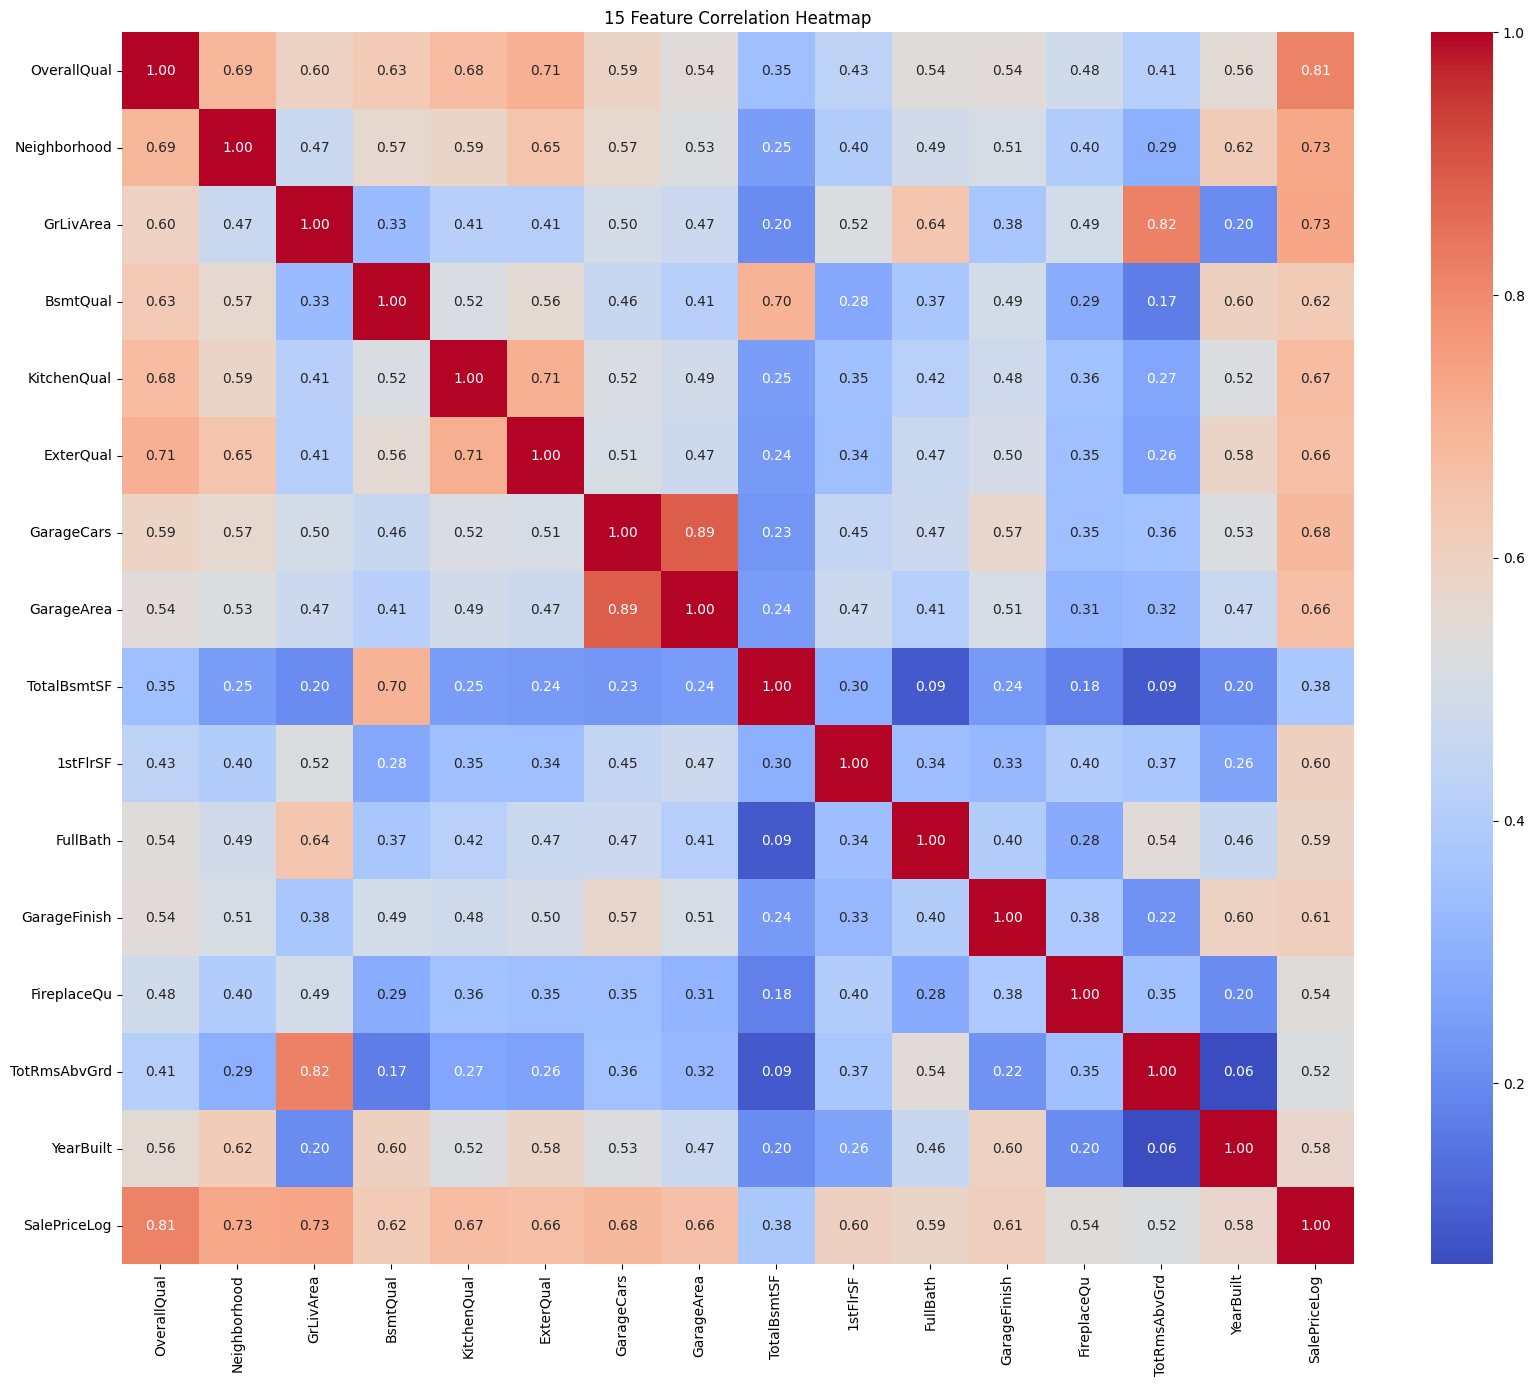

In [58]:
plt.figure(figsize=(20,16))
sns.heatmap(corr_matrix_15, annot = True, fmt ='.2f',cmap='coolwarm',square=True)
plt.title("15 Feature Correlation Heatmap")
plt.show()

# 大面積的精細篩選的熱力圖

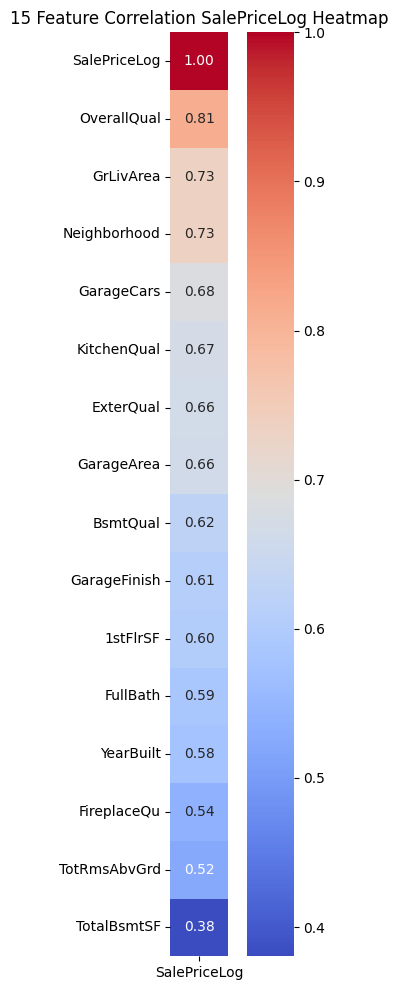

In [59]:
# 僅針對房價的相關係數之熱力圖
plt.figure(figsize=(5,12))
sns.heatmap(target_corrMatrix, annot = True, fmt ='.2f',cmap='coolwarm',square=True)
plt.title("15 Feature Correlation SalePriceLog Heatmap")
plt.show()


### 套用線性模型

In [60]:
import statsmodels.api as sm

In [61]:
# 加截距
X_train_scaledWithC = sm.add_constant(X_train_scaled)
X_test_scaledWithC = sm.add_constant(x_test_scaled)

In [62]:
# 送入模型 osm
ols_model = sm.OLS(logY_train,X_train_scaledWithC).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     500.2
Date:                Mon, 17 Aug 2026   Prob (F-statistic):               0.00
Time:                        09:49:00   Log-Likelihood:                 617.78
No. Observations:                1166   AIC:                            -1204.
Df Residuals:                    1150   BIC:                            -1123.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           12.0306      0.004   2864.024   

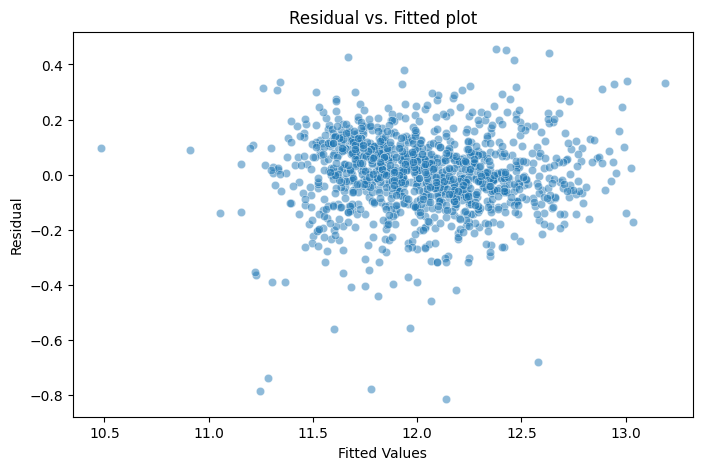

In [63]:
# 確認 OLS 的學習結果符合同質變異數與誤差獨立性
# 同質變異數檢查


plt.figure(figsize = (8,5))
sns.scatterplot(x=ols_model.fittedvalues, y = ols_model.resid, alpha = 0.5)
plt.title('Residual vs. Fitted plot')
plt.xlabel('Fitted Values')
plt.ylabel('Residual')
plt.show()

In [64]:
import statsmodels.stats.diagnostic as diagnostic

In [65]:
bp_test = diagnostic.het_breuschpagan(ols_model.resid ,ols_model.model.exog)
titles = ['Lagrange multiplier statistic','p-value','f-statistic','f-pvalue']
for i in range(len(titles)):
    print (f"{titles[i]}:{bp_test[i]:.5f} ",)


Lagrange multiplier statistic:58.01435 
p-value:0.00000 
f-statistic:4.01428 
f-pvalue:0.00000 


##### 同質變異數與誤差獨立檢查結果
顯然 Breusch-Pagan 檢定的 p value < 0.05 所以有異質性問題，而 Kurtosis 來到 6 以上，明顯超越標準 3 。
繼續嘗試由其他方式調查指標呈現異質變異數的原因。

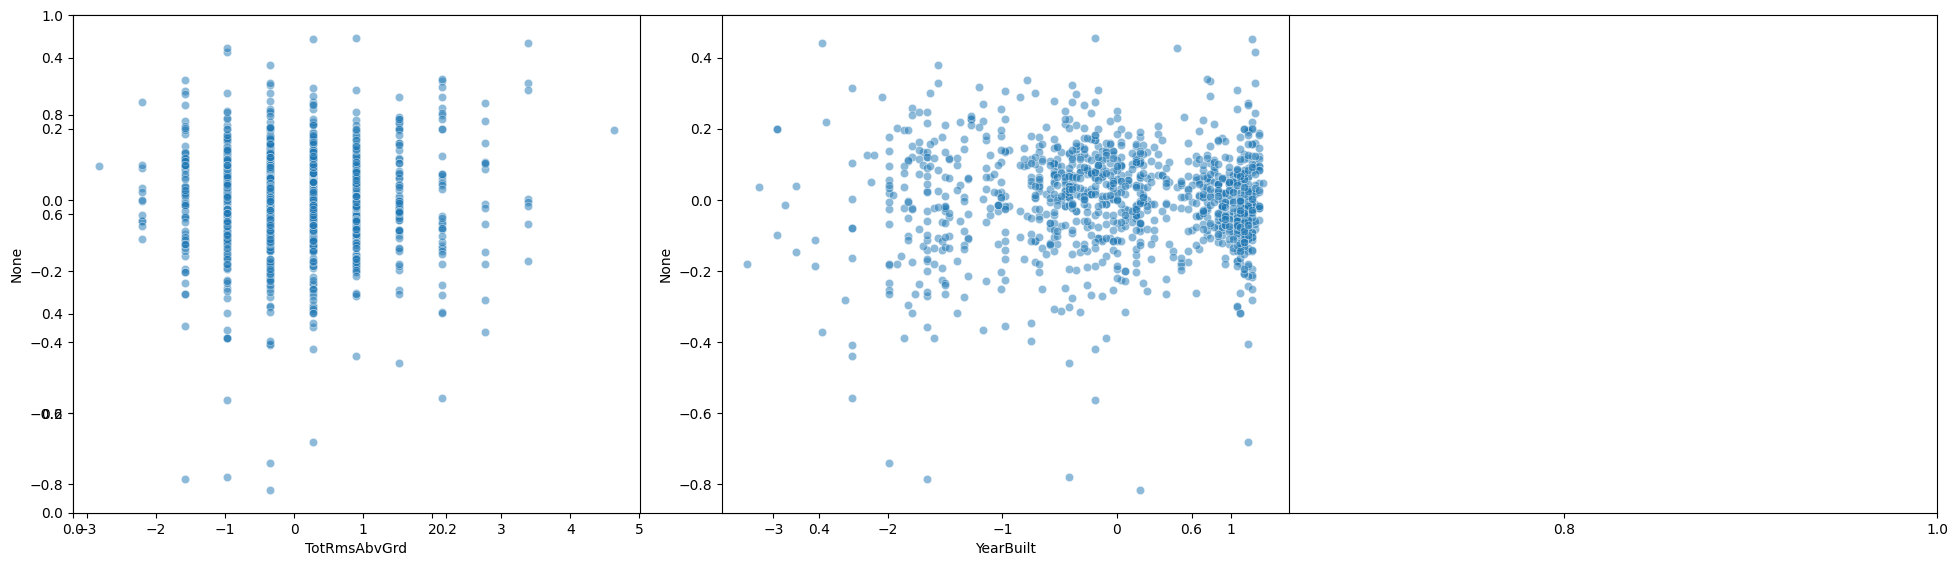

In [66]:
# 散佈圖。找出可能的異質變異數，先看之前中等偏移的欄位
plt.subplots(figsize=(20,6))

location =1
for (i) in ['TotRmsAbvGrd','YearBuilt']:
    plt.subplot(1,3,location)
    sns.scatterplot(x=X_train_scaledWithC[i],y = ols_model.resid,alpha=0.5)
    location += 1
plt.tight_layout()

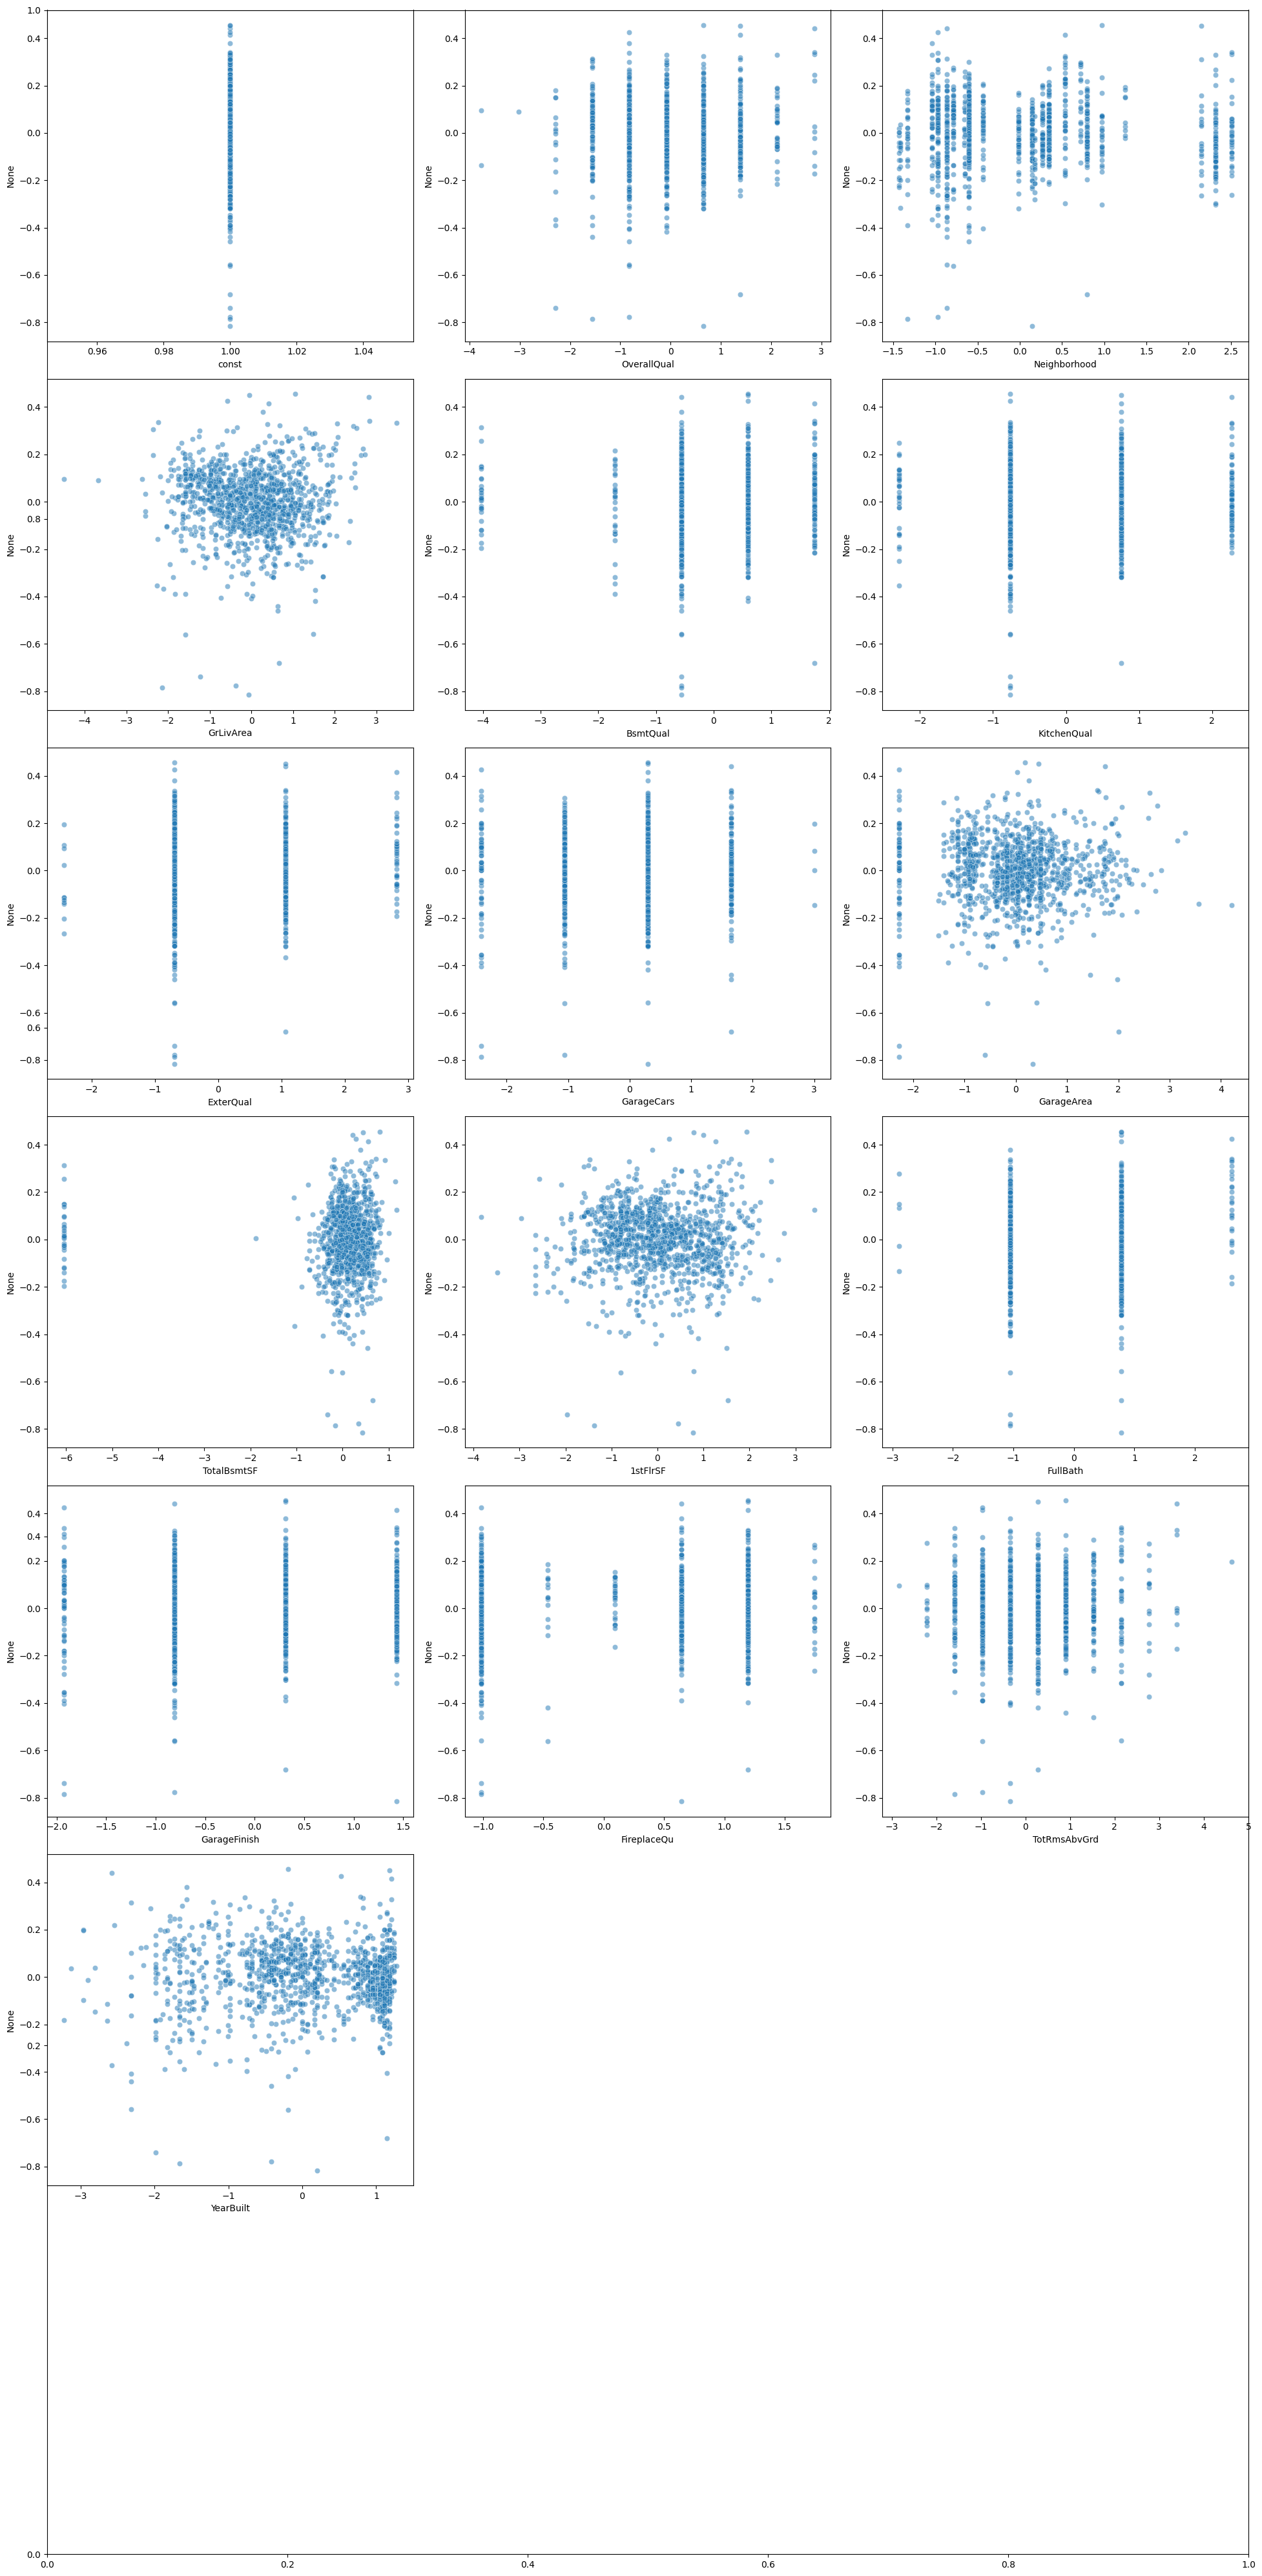

In [67]:
# 散佈圖。找出可能的異質變異數，看全部的指標
plt.subplots(figsize=(20,40))

location =1
for (i) in X_train_scaledWithC.columns.tolist():
    plt.subplot(7,3,location)
    sns.scatterplot(x=X_train_scaledWithC[i],y = ols_model.resid,alpha=0.5)
    location += 1
plt.tight_layout()


##### 異質變異數檢查
從散佈圖中並未找出明顯有喇叭狀的圖形。因此改找資料中是否有超過三倍標準差的殘差分佈狀況的項目。

In [68]:
# 先看看是不是有沒踢乾淨的離峰值
print(ols_model.resid.sort_values().head(5))
print(ols_model.resid.sort_values().tail(5))

632    -0.815916
495    -0.785522
410    -0.777702
968    -0.739392
1324   -0.680460
dtype: float64
1181    0.415032
738     0.425728
185     0.440912
688     0.450943
313     0.455445
dtype: float64


In [69]:
resid_std = np.std(ols_model.resid)
outlier_id = ols_model.resid[np.abs(ols_model.resid) > 3 * resid_std].index

In [70]:
# 將這些殘差位於超過三個標準差的資料，撈出來看看高相關指標的表現
df_dropped.loc[outlier_id,['SalePrice','Neighborhood','OverallQual','GrLivArea','GarageCars','ExterQual']]

,SalePrice,Neighborhood,OverallQual,GrLivArea,GarageCars,ExterQual
462,62383,Sawyer,5,864,1,TA
410,60000,Edwards,5,1276,1,TA
1324,147000,Somerst,8,1795,3,Gd
676,87000,OldTown,4,1774,3,TA
968,37900,OldTown,3,968,0,TA
495,34900,IDOTRR,4,720,0,TA
185,475000,OldTown,10,3608,3,Gd
688,392000,StoneBr,8,1419,2,Gd
728,110000,NAmes,5,1776,3,TA
313,375000,Timber,7,2036,2,TA


In [71]:
X_train_scaledClean = X_train_scaledWithC.drop(index = outlier_id)
Y_trainClean = Y_OLS_Train.drop(index = outlier_id)
logY_trainClean = logY_train.drop(index = outlier_id)

In [72]:
# 再送一次 OLS 模型

olsModel2 =sm.OLS(logY_trainClean,X_train_scaledClean).fit()
print(olsModel2.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                     590.6
Date:                Mon, 17 Aug 2026   Prob (F-statistic):               0.00
Time:                        09:49:11   Log-Likelihood:                 730.55
No. Observations:                1154   AIC:                            -1429.
Df Residuals:                    1138   BIC:                            -1348.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           12.0345      0.004   3159.546   

In [73]:
bp_test02 = diagnostic.het_breuschpagan(olsModel2.resid ,olsModel2.model.exog)
titles = ['Lagrange multiplier statistic','p-value','f-statistic','f-pvalue']
for i in range(len(titles)):
    print (f"{titles[i]}:{bp_test02[i]:.5f} ",)

Lagrange multiplier statistic:103.86190 
p-value:0.00000 
f-statistic:7.50345 
f-pvalue:0.00000 


##### 同質變異數與誤差獨立檢查結果
雖然 BP 檢定的 p value < 0.05 以及 Omnibus, JB 檢定顯示仍有異質性問題，若要嚴格符合資料常態分佈，將會繼續刪除資料，導致繼續破壞資料母體樣貌。而 summary 其他模型指標，如 Skew = -0.17 及 Kurtosis 已經回歸較標準的範圍，顯示偏移問題明顯改善。加上 $R^2$ 指標也提升，顯示此次「踢除極端離群值後」之模型解釋力提升。顯然第二次 OLS 線性模型的評估表現優於第一次。綜合以上，本次模型之 summary 的報表可信度較高。可依據表格中 p-value 判斷各項指標之去留。

In [74]:
# 欄位很多項，將 p-value > 0.05 的指標提出來
Xtrain_15_pvalue = olsModel2.pvalues

unsig_vars = Xtrain_15_pvalue[Xtrain_15_pvalue> 0.05].index.tolist()
significant_columns = Xtrain_15_pvalue[Xtrain_15_pvalue < 0.05].index.tolist()


In [75]:
# 精煉 columns 排除 p value > 0.05 ，訓練精簡化模型
X_trained_conscise = X_train_scaledClean[significant_columns]

In [76]:
# 再送一次 OLS 模型，訓練精簡化模型
olsModel_11 =sm.OLS(logY_trainClean,X_trained_conscise).fit()
print(olsModel_11.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                     805.1
Date:                Mon, 17 Aug 2026   Prob (F-statistic):               0.00
Time:                        09:49:11   Log-Likelihood:                 728.62
No. Observations:                1154   AIC:                            -1433.
Df Residuals:                    1142   BIC:                            -1373.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           12.0346      0.004   3159.897   

In [77]:
# 將 p-value > 0.05 的指標提出來確認
Xtrain_11_pvalue = olsModel_11.pvalues

unsig_vars_11 = Xtrain_11_pvalue[Xtrain_11_pvalue> 0.05].index.tolist()
significant_11_columns = Xtrain_11_pvalue[Xtrain_11_pvalue < 0.05].index.tolist()
unsig_vars_11
# 確認已經沒有 p_value > 0.05 的指標，則此模型完工。

[]

#### 套用 x_test
最精簡的 OLS 模型已然出現。
其 $R^2$ 分數、AIC、BIC 數字都比前一次好，且沒有任何 p value > 0.05

In [78]:
x_test11 = X_test_scaledWithC[significant_columns]

In [79]:
#logy_test x_test_scaled
logy_predict = olsModel_11.predict(x_test11)

In [80]:
# 過度擬合相關檢查函數
def model_check(model,modelname,x_train,y_train,x_test,y_test):
    ytest_pred = model.predict(x_test)
    ytrain_pred = model.predict(x_train)
    r2 = r2_score(y_test,ytest_pred)
    test_mae = mean_absolute_error(y_test,ytest_pred)
    test_rmse = np.sqrt( mean_squared_error(y_test,ytest_pred))
    train_rmse = np.sqrt(mean_squared_error(y_train,ytrain_pred))
    ytest_mean = y_test.mean()
    MAPE = test_mae/ ytest_mean
    rmse_degra = (test_rmse - train_rmse)/train_rmse
    rmse_gap = test_rmse - train_rmse
    MAPE_percent = MAPE*100
    CV_Rmse = test_rmse/ytest_mean
    CV_Rmse_percent = CV_Rmse*100


    # 輸出成果
    print(f"{modelname} 的檢查：")
    print(f"測試集的MAE 平均絕對誤差 (log)：{test_mae:.5f}")
    print(f"測試集的y 平均(log)：{ytest_mean:.5f}")
    print(f"測試集的 WMAPE 平均絕對百分比誤差(log)：{MAPE:.5f} = {MAPE_percent:.3f}%")
    print(f"測試集的 CV(RMSE) 百分比誤差(log)：{CV_Rmse:.5f} = {CV_Rmse_percent:.3f}%")
    print(f"R 分數：{r2:.2f}")
    print("-- -- --")
    print(f"測試集的 rmse 均方根誤差(log)：{test_rmse:.5f}")
    print(f"訓練集的 rmse 均方根誤差(log)：{train_rmse:.5f}")
    print(f"RMSE GAP (測試-訓練)：{rmse_gap:.5f}")
    print(f"rmse degradation(log)：{rmse_degra:.5f}")
    print("-- -- --")
    print("-- -- --")
    print("過度擬合判斷結果：")
    if rmse_degra > 0.15:
        print(f"          可能過度擬合")
    elif MAPE > 0.1:
        print(f"          可能擬合不足")
    else:
        print(f"          目前安全")



In [81]:
model_check(olsModel_11,"olsModel_11",X_trained_conscise,logY_trainClean,x_test11,logy_test)

olsModel_11 的檢查：
測試集的MAE 平均絕對誤差 (log)：0.10892
測試集的y 平均(log)：11.99765
測試集的 WMAPE 平均絕對百分比誤差(log)：0.00908 = 0.908%
測試集的 CV(RMSE) 百分比誤差(log)：0.01317 = 1.317%
R 分數：0.87
-- -- --
測試集的 rmse 均方根誤差(log)：0.15805
訓練集的 rmse 均方根誤差(log)：0.12869
RMSE GAP (測試-訓練)：0.02936
rmse degradation(log)：0.22813
-- -- --
-- -- --
過度擬合判斷結果：
          可能過度擬合


Text(0, 0.5, 'Real Data')

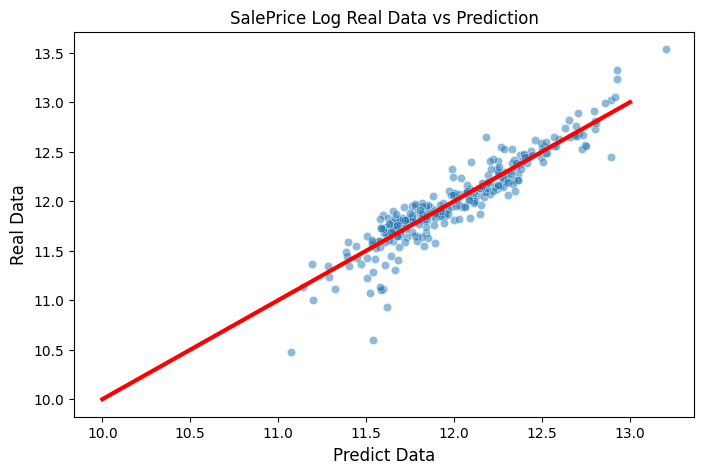

In [82]:
plt.figure(figsize = (8,5))
plt.title("SalePrice Log Real Data vs Prediction")
sns.scatterplot(x = logy_predict, y = logy_test,alpha = 0.5)
a = np.linspace(10,13,100)
plt.plot(a,a, color = 'red',label = "line",linewidth = 3)
plt.xlabel("Predict Data", fontsize = 12)
plt.ylabel("Real Data", fontsize = 12)

In [83]:
kaggletestdf = pd.read_csv("test.csv")

In [84]:
# 先找出原本 15 項
kaggletest_df15 = kaggletestdf[corr_Over5_df.T_columns[1:]]
kaggletest_df15.head(5)

,OverallQual,Neighborhood,GrLivArea,BsmtQual,KitchenQual,ExterQual,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,GarageFinish,FireplaceQu,TotRmsAbvGrd,YearBuilt
0,5,NAmes,896,TA,TA,TA,1.0,730.0,882.0,896,1,Unf,NaN,5,1961
1,6,NAmes,1329,TA,Gd,TA,1.0,312.0,1329.0,1329,1,Unf,NaN,6,1958
2,5,Gilbert,1629,Gd,TA,TA,2.0,482.0,928.0,928,2,Fin,TA,6,1997
3,6,Gilbert,1604,TA,Gd,TA,2.0,470.0,926.0,926,2,Fin,Gd,7,1998
4,8,StoneBr,1280,Gd,Gd,Gd,2.0,506.0,1280.0,1280,2,RFn,NaN,5,1992


In [85]:
# data process 處理
kaggletest_15_processed = LinearStat_process(kaggletest_df15)

In [86]:
# 標準化
kaggletest_scaled = scaler.transform(kaggletest_15_processed)

In [87]:
# 加上常數項
kaggletestWithC = sm.add_constant(kaggletest_scaled)

In [88]:
# 只保留剩下 11 項指標

kaggletest_11= kaggletestWithC[x_test11.columns]

In [89]:
# 模型預測並轉回原數值
prediction_log = olsModel_11.predict(kaggletest_11)
prediction_Saleprice = np.expm1(prediction_log)

In [90]:
# 轉成 kaggle 指定提交檔案類型
submitPrice = pd.DataFrame({"Id":kaggletestdf['Id'],'SalePrice':prediction_Saleprice })
submitPrice.to_csv('submission_1.csv', index=False)

#### Kaggle 分數
OLS 模型與 11 項指標的 public Score 為 0.15940 ，非常接近測試集的 rmse
排名為 3808。

本次專案目標為提升房價預測準確度，目前已透過 OLS 線性模型盡可能精準的找出相關的指標，將以此結果為基準線，接下來將試圖套用樹模型等機器學習的方法，看有無提升表現。

### 機器學習模型
機器學習相對不受極端值影響，但是房價 Y 的極端值仍會影響機器學習的結果，為求保險起見，應該先刪除明顯離峰值，在進行資料切割、轉碼等流程。
按照相關係數高低刪除最高相關指標中，散佈圖右下角之資料，於 OLS 模型錢資料清洗以找出來兩組 id，故將沿用刪除該兩筆離峰值之資料繼續流程。


In [91]:
# 原始資料複製出來
df_raw = pd.concat([X_Trainee,Y_Trainee], axis = 1)

In [92]:
X_trainML_large  = X_Trainee.copy()
Y_trainML_large = Y_Trainee.copy()
x_test_ML = x_test.copy()
y_test_ML = y_test.copy()
X_trainML_small = X_Train.copy()
Y_Train_small = Y_Train.copy()
X_Val_ML = X_Val.copy()
y_Val_ML = y_Val.copy()

In [93]:
logY_trainML = np.log1p(Y_trainML_large)
logy_testML = np.log1p(y_test_ML)
logy_Val = np.log1p(y_Val_ML)
logy_train_small = np.log1p(Y_Train_small)

In [94]:
# 區分欄位型態，數值與文字型態的清洗與替補邏輯不同，建立欄位型態與缺失值表格，方便整理每項欄位的處理方式。
dfraw_objectCols = df_raw.select_dtypes(include=["object"]).columns

In [95]:
nullcheck = df_raw.isnull().sum()
nullcheckdf = nullcheck.to_frame().reset_index().rename(columns=({'index':'Columns',0:'nullCnt'}))

In [96]:
rawdfType = pd.DataFrame({'dfCols':df_raw.columns})
rawdfType['dtype'] = np.where((rawdfType['dfCols'].isin(dfraw_objectCols.tolist())),'object','float')
rawdfType = pd.merge(rawdfType,nullcheckdf,left_on='dfCols',right_on = 'Columns',how = 'left').drop('Columns',axis = 1)
nullFloatCols = rawdfType[(rawdfType['nullCnt']>0)&(rawdfType['dtype'] == 'float' )]
nullObejctCols = rawdfType[(rawdfType['nullCnt']>0)&(rawdfType['dtype'] == 'object' )]
objecttransferCols = rawdfType[(rawdfType['nullCnt'] == 0)&(rawdfType['dtype'] == 'object' )]
floatFULLCols = rawdfType[(rawdfType['nullCnt'] == 0)&(rawdfType['dtype'] == 'float' )]


print (f"數值型態有缺失之欄位：{nullFloatCols}")
print (f"文字型態有缺失之欄位：{nullObejctCols}")
print (f"文字型態無缺失但需轉碼之欄位:{objecttransferCols}")
print (f"數值型態無缺失但需轉碼之欄位:{floatFULLCols}")

數值型態有缺失之欄位：         dfCols  dtype  nullCnt
3   LotFrontage  float      217
26   MasVnrArea  float        6
59  GarageYrBlt  float       64
文字型態有缺失之欄位：          dfCols   dtype  nullCnt
6          Alley  object     1092
25    MasVnrType  object      683
30      BsmtQual  object       28
31      BsmtCond  object       28
32  BsmtExposure  object       28
33  BsmtFinType1  object       28
35  BsmtFinType2  object       28
42    Electrical  object        1
57   FireplaceQu  object      547
58    GarageType  object       64
60  GarageFinish  object       64
63    GarageQual  object       64
64    GarageCond  object       64
72        PoolQC  object     1161
73         Fence  object      933
74   MiscFeature  object     1120
文字型態無缺失但需轉碼之欄位:           dfCols   dtype  nullCnt
2        MSZoning  object        0
5          Street  object        0
7        LotShape  object        0
8     LandContour  object        0
9       Utilities  object        0
10      LotConfig  object        0
11      Land

##### 數值型態的缺失值做法：
- LotFrontage: 補中位數。
- MasVnrArea: 補0 因為對應的地磚型態為 none
- GarageYrBlt: 跟下方文字型態的 Garage 系列一樣有 64 項缺失值，故可推估是沒有車庫的設施。因為無設施所以補 0

##### 文字型態的缺失值、替換做法：
- Alley: 根據手冊定義轉類別，缺失值補 NA
- MasVnrType:根據手冊定義轉類別，其中五筆補眾數，其餘補 NA
- BsmtQual:根據手冊定義轉五階定義，缺失值補 NA
- BsmtCond:根據手冊定義轉五階定義，缺失值補 NA
- BsmtExposure:根據手冊轉自定義，缺失值補 NA 條件缺失值補眾數、 需自訂轉換器。
- BsmtFinType1:根據手冊轉自定義，缺失值補 NA
- BsmtFinType2:根據手冊轉自定義，缺失值補 NA 條件缺失值補眾數 需自訂轉換器。
- Electrical:根據手冊轉自定義，缺失值補眾數 需自動轉換器
- FireplaceQu:根據手冊定義轉五階定義，缺失值補 NA
- GarageType:根據手冊定義轉類別，缺失值補 NA
- GarageFinish:根據手冊轉自定義，缺失值補 NA
- GarageQual: 根據手冊定義轉五階定義，缺失值補 NA
- GarageCond:根據手冊定義轉五階定義，缺失值補 NA
- PoolQC:根據手冊轉自定義，缺失值補 NA
- Fence:根據手冊轉自定義，缺失值補 NA
- MiscFeature:根據手冊定義轉類別，缺失值補 NA

In [97]:
# 有缺失篩選不同轉碼 list

#自訂轉換器
#其中五筆 MasVnrType df_raw[(df_raw['MasVnrType'].isnull())*(df_raw['MasVnrArea']>0)] 要補眾數

#數值缺失需用 simpleimputer
FILLNA0 = ['MasVnrArea','GarageYrBlt','BsmtFinSF1','BsmtFinSF2','BsmtFullBath','BsmtUnfSF','TotalBsmtSF','GarageArea','GarageCars','BsmtHalfBath']


#先補 NA 才可以轉碼
FILLNA_NA = ['Alley','GarageQual','MasVnrType','BsmtQual','BsmtCond','BsmtFinType1','BsmtExposure','BsmtFinType2','FireplaceQu','GarageType','GarageFinish','GarageCond','PoolQC','Fence','MiscFeature']
NAwithMode = ['Electrical','HeatingQC','KitchenQual','ExterQual','ExterCond','LotShape','LandContour','Utilities','LotConfig','LandSlope'
,'HouseStyle','CentralAir','Functional','PavedDrive','Neighborhood','Exterior1st','Exterior2nd','Condition1','Condition2','SaleType','RoofMatl'
,'SaleCondition','Heating','RoofStyle','GarageType','Foundation']

# 數值類型指標
NAwithMediumList = ['LotFrontage']
NAwithMeanList = ['']

# 文字類型指標
OneHot = ['Alley','MasVnrType','MiscFeature','Street','MSZoning','BldgType']
AsCate_Target = ['Neighborhood','Exterior1st','Exterior2nd','Condition1','Condition2','SaleType','RoofMatl','SaleCondition','Heating','RoofStyle','GarageType','Foundation']


#小眾的 Ordinal 指標 從 0
ordinal=['BsmtExposure','BsmtFinType1','BsmtFinType2','Electrical','GarageFinish','PoolQC','Fence']
BsmtExposure_Ordi = ['NA','No','Mn','Av','Gd']
GarageFinish_Ordi = ['NA','Unf','RFn','Fin']
Electrical_Ordi = ['Mix','FuseP','FuseF','FuseA','SBrkr']
PoolQC_Ordi = ['NA','Fa','TA','Gd','Ex']
Fence_Ordi=['NA','MnWw','GdWo','MnPrv','GdPrv']

Ordina_with_NA = ['Fence','PoolQC','GarageFinish','BsmtExposure']

#bsmtfintype 共用
BsmtFinType_Ordi = ['NA','Unf','LwQ','Rec','BLQ','ALQ','GLQ']
BsmtFinType_OrdList = ['BsmtFinType1','BsmtFinType2']

#大眾的 6 Ordinal 指標
sixgradeList = ['BsmtQual','BsmtCond','FireplaceQu','GarageQual','GarageCond']
sixgradeForOrd = ['NA','Po','Fa','TA','Gd','Ex']

#相似的 5 ordinal 指標 以下均無 miss
fivegradeList = ['HeatingQC','KitchenQual','ExterQual','ExterCond']
fivegradeForOrd = ['Po','Fa','TA','Gd','Ex']



In [98]:
for a in OneHot:
    print (f"{a} 欄位有 {df_raw[a].nunique()} 個項目。")


Alley 欄位有 2 個項目。
MasVnrType 欄位有 3 個項目。
MiscFeature 欄位有 4 個項目。
Street 欄位有 2 個項目。
MSZoning 欄位有 5 個項目。
BldgType 欄位有 5 個項目。


##### 資料清理 pipeline 分組：
###### 數值型態
- 層級 A01:缺失值補0
- 層級 A02:缺失值補中位數
##### 文字型態
- 層級 C01:先補缺失值 NA
- 層級 B01:
    - 先補特殊條件
- 層級 B02:
    - 層級 C01
    - 再轉 One Hot Encode
- 層級 B03:
    - 層級 C01
    - 再轉 Ordinal
- 層級 B04:
    - 層級 C01
    - 再轉 小眾 Ordinal
- 層級 A03:
    - 層級 B01
    - 層級 B02
- 層級 A04:
    - 層級 B01
    - 層級 B03
- 層級 A05-1:
    - 層級 B01
    - 層級 B04
- 層級 A06:轉 Ordinal
- 層級 A07: 轉 小眾 Ordinal
- 層級 A08: 轉 one hot encode

In [99]:
# 無缺失值之文字型態轉碼

LotShape_Ordi = ['IR3','IR2','IR1','Reg'] #LotShape
LandContour_Ordi = ['Low','HLS','Bnk','Lvl']
Utilities_Ordi = ['ELO','NoSeWa','NoSewr','AllPub']
LotConfig_Ordi = ['FR3','FR2','CulDSac','Corner','Inside']
LandSlope_Ordi = ['Sev','Mod','Gtl']
HouseStyle_Ordi = ['SLvl','SFoyer','1Story','1.5Unf','1.5Fin','2Story','2.5Unf','2.5Fin']
CentralAir_Ordi = ['N','Y']
Functional_Ordi= ['Sal','Sev','Maj2','Maj1','Mod','Min2','Min1','Typ']
PavedDrive_Ordi = ['N','P','Y']

##### pipeline 實驗

In [100]:
#  fillnawithNA C01
fillnawithNA = Pipeline(steps=[('imputer',SimpleImputer(strategy='constant', fill_value='NA'))])

In [101]:
# 缺失值補 NA 的指定函數
def NawithNA(X,TargetCol):
    XCp = X.copy()
    for col in TargetCol:
        XCp[col] =XCp[col].fillna('NA')
    return XCp


Nawith_NA = FunctionTransformer(func = NawithNA,kw_args = {'TargetCol':FILLNA_NA})

In [102]:
#  fillnawith0 C01
fillnawith0 = Pipeline(steps=[('imputer',SimpleImputer(strategy='constant', fill_value=0))])

In [103]:
# pipeline for fillnawithNA and as one Hot B02
fillNAandOneHot = Pipeline(steps=[('fillnawithNApipe',fillnawithNA),('asOneHot',OneHotEncoder(min_frequency=0.2, sparse_output=False, handle_unknown='infrequent_if_exist'))])

In [104]:
# pipeline for fillnawithNA and as Ordianl B03 public
fillNAandOrdi = Pipeline(steps=[
    ('fillnawithNApipe',fillnawithNA),
     ('as6LevelOdinal',OrdinalEncoder(categories=[sixgradeForOrd] *len(sixgradeList)))
     ])

In [105]:
fillNaAsTarget= Pipeline(steps=[('fillnawithNApipe',fillnawithNA),('astarget',ce.TargetEncoder(cols=AsCate_Target))])

In [106]:
def to_category(X):
    return X.astype('category')
lgb_AsCate = FunctionTransformer(to_category,feature_names_out='one-to-one')

In [107]:
fillNaAsCate= Pipeline(steps=[('fillnawithNApipe',fillnawithNA),('asCate',lgb_AsCate)])

In [108]:
# pipeline for fillnawithNA and as Ordianl B04-2
BsmtFinTypeOrdiPipe = Pipeline(steps=[
    ('fillnawithNApipe',fillnawithNA),
     ('BsmtFinType_Ordinal',OrdinalEncoder(categories=[BsmtFinType_Ordi]*len(BsmtFinType_OrdList)))
     ])

In [109]:
# pipeline for fillnawithNA and as Ordianl B04-3
GarageFinishOrdiPipe = Pipeline(steps=[
    ('fillnawithNApipe',fillnawithNA),
     ('GarageFinish_Ordinal',OrdinalEncoder(categories=[GarageFinish_Ordi]))
     ])

In [110]:
# pipeline for fillnawithNA and as Ordianl B04-4
PoolQCOrdiPipe = Pipeline(steps=[
    ('fillnawithNApipe',fillnawithNA),
     ('PoolQC_Ordinal',OrdinalEncoder(categories=[PoolQC_Ordi]))
     ])

In [111]:
# pipeline for fillnawithNA and as Ordianl B04-5
FenceOrdiPipe = Pipeline(steps=[
    ('fillnawithNApipe',fillnawithNA),
     ('Fence_Ordinal',OrdinalEncoder(categories=[Fence_Ordi]))
     ])

In [112]:
# 特殊條件
class ConditionalImputerMode(BaseEstimator,TransformerMixin):
    def __init__ (self,TargetCol,checkCol):
        self.TargetCol = TargetCol
        self.checkCol = checkCol
        self.fill_value = None #眾數用

    def fit(self, X, y= None):
        self.fill_value = X[self.TargetCol].mode()[0]
        return self

    def transform(self, X):
        XCp = X.copy()
        mask = (XCp[self.checkCol] >0 )&  (XCp[self.TargetCol].isnull())
        XCp.loc[mask,self.TargetCol] = self.fill_value
        return XCp

In [113]:
# MasVnrType 的特殊條件填補 B01-1
MasVnrType_ConditionfillMode_pipe = Pipeline(steps=[('imputer',ConditionalImputerMode(TargetCol='MasVnrType',checkCol='MasVnrArea'))])

In [114]:
# pipeline for fillnawithNA and as Ordianl B04-1
BsmtExposureOrdipipe = Pipeline(steps=[('fillnawithNApipe',fillnawithNA),
     ('BsmtExposure_Level',OrdinalEncoder(categories=[BsmtExposure_Ordi]))
     ])


In [115]:
# 特殊條件  用
class ImputerMode(BaseEstimator,TransformerMixin):
    def __init__ (self,TargetCol):
        self.TargetCol = TargetCol
        self.fill_value = {} #眾數用

    def fit(self, X, y= None):
        for col in self.TargetCol:
            self.fill_value[col] = X[col].mode()[0]
        return self

    def transform(self, X):
        XCp = X.copy()
        for col in self.TargetCol:
            mask = (XCp[col].isnull())
            XCp.loc[mask,col] = self.fill_value[col]
        return XCp

In [116]:
electricPipetest = Pipeline(steps=[('imputer',ImputerMode(TargetCol = 'Electrical'))])

In [117]:
# 五階沒有 NA 若有缺失值要補 mode
FivegradeOrdipipe = Pipeline(steps=[('imputer',ImputerMode(TargetCol = fivegradeList)),
     ('5gradeordiLevel',OrdinalEncoder(categories=[fivegradeForOrd] *len(fivegradeList)))
     ])
('5gradeordi',FivegradeOrdipipe,fivegradeList)

('5gradeordi',
 Pipeline(steps=[('imputer',
                  ImputerMode(TargetCol=['HeatingQC', 'KitchenQual', 'ExterQual',
                                         'ExterCond'])),
                 ('5gradeordiLevel',
                  OrdinalEncoder(categories=[['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                                             ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                                             ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                                             ['Po', 'Fa', 'TA', 'Gd', 'Ex']]))]),
 ['HeatingQC', 'KitchenQual', 'ExterQual', 'ExterCond'])

In [118]:
LotShapeOrdipipe = Pipeline(steps=[('fillnawithNApipe',fillnawithNA),
     ('LotShape_Level',OrdinalEncoder(categories=[LotShape_Ordi]))
     ])
('LotShape_Ord',LotShapeOrdipipe,['LotShape'])

('LotShape_Ord',
 Pipeline(steps=[('fillnawithNApipe',
                  Pipeline(steps=[('imputer',
                                   SimpleImputer(fill_value='NA',
                                                 strategy='constant'))])),
                 ('LotShape_Level',
                  OrdinalEncoder(categories=[['IR3', 'IR2', 'IR1', 'Reg']]))]),
 ['LotShape'])

In [119]:
# 特殊條件 LotFrontage 數值型態補中位數
class ImputerMedian(BaseEstimator,TransformerMixin):
    def __init__ (self,TargetCol):
        self.TargetCol = TargetCol
        self.fill_value = {} #中位數

    def fit(self, X, y= None):
        for col in self.TargetCol:
            self.fill_value[col] = X[col].median()
        return self

    def transform(self, X):
        XCp = X.copy()
        for col in self.TargetCol:
            XCp[col] = XCp[col].fillna(self.fill_value[col])
            XCp[col] = XCp[col].astype(float)
        return XCp

In [120]:
LotFrontage_Pipetest =  Pipeline(steps=[('imputer',ImputerMedian(TargetCol = 'LotFrontage'))])

In [121]:
# 特殊條件 MasVnrArea
def ConditionNawith0(X):
    XCp = X.copy()
    mask = (XCp['MasVnrType'].isnull() )&  (XCp['MasVnrArea'].isnull())
    XCp.loc[mask,'MasVnrArea'] = 0
    return XCp


ConditionNawith0 = FunctionTransformer(ConditionNawith0)

In [122]:
MasVnrArea_Conditionfill0_pipe = Pipeline(steps=[('imputer',ConditionNawith0)])

In [123]:
# 特殊條件 GarageYrBlt  沒設條件因為有本次資料不需篩選
def Nawith0(X,TargetCol):
    XCp = X.copy()
    for col in TargetCol:
        XCp[col] =XCp[col].fillna(0)
    return XCp


Nawith0 = FunctionTransformer(func = Nawith0,kw_args = {'TargetCol':FILLNA0})

In [124]:
GarageYrBlt_fill0_pipe = Pipeline(steps=[('imputer',Nawith0)])

In [125]:
# 數值型態缺失都補 0
def all_Nawith0(X):
    XCp = X.copy()
    num_columns = XCp.select_dtypes(include=[np.number]).columns
    for col in num_columns:
        XCp[col] =XCp[col].fillna(0)
    return XCp


all_Nawith0 = FunctionTransformer(func = all_Nawith0,feature_names_out = 'one-to-one')

In [126]:
# 文字型態缺失都補 NA
def all_NawithNA(X):
    XCp = X.copy()
    num_columns = XCp.select_dtypes(exclude=[np.number]).columns
    for col in num_columns:
        XCp[col] =XCp[col].fillna('NA')
    return XCp


all_NawithNA = FunctionTransformer(func = all_NawithNA,feature_names_out = 'one-to-one')

In [127]:
# final columntransformer
tree_Column_preprocess = ColumnTransformer(
    transformers=[('NAandOneHot',fillNAandOneHot,OneHot),
('NAand5Ordi',fillNAandOrdi,sixgradeList),
                  ('NaandAsTarget',fillNaAsTarget,AsCate_Target),
 ('BsmtExposureOrd',BsmtExposureOrdipipe,['BsmtExposure']),
  ('BsmtFinTypeOrd',BsmtFinTypeOrdiPipe,BsmtFinType_OrdList),
    ('GarageFinishOrd',GarageFinishOrdiPipe,['GarageFinish']),
     ('PoolQCOrd',PoolQCOrdiPipe,['PoolQC']),
     ('FenceOrd',FenceOrdiPipe,['Fence']),
       ('ElectricalOrd',OrdinalEncoder(categories=[Electrical_Ordi]),['Electrical']),
                  ('5gradeordi',OrdinalEncoder(categories=[fivegradeForOrd] *len(fivegradeList)),fivegradeList),
                  ('LotShape_Ord',OrdinalEncoder(categories=[LotShape_Ordi]),['LotShape']),
('LandContour_Ord',OrdinalEncoder(categories=[LandContour_Ordi]),['LandContour']),
                  ('Utilities_Ordi',OrdinalEncoder(categories=[Utilities_Ordi]),['Utilities']),
                  ('LotConfig_Ordi',OrdinalEncoder(categories=[LotConfig_Ordi]),['LotConfig']),
                  ('LandSlope_Ordi',OrdinalEncoder(categories=[LandSlope_Ordi]),['LandSlope']),
                  ('HouseStyle_Ordi',OrdinalEncoder(categories=[HouseStyle_Ordi]),['HouseStyle']),
                  ('CentralAir_Ordi',OrdinalEncoder(categories=[CentralAir_Ordi]),['CentralAir']),
                  ('Functional_Ordi',OrdinalEncoder(categories=[Functional_Ordi]),['Functional']),
                  ('PavedDrive_Ordi',OrdinalEncoder(categories=[PavedDrive_Ordi]),['PavedDrive']),
       ],remainder='passthrough')

In [128]:
lgb_Column_preprocess = ColumnTransformer(
    transformers=[('NAandOneHot',fillNAandOneHot,OneHot),
('NAand5Ordi',fillNAandOrdi,sixgradeList),
                  ( 'NaandAsCate',fillNaAsCate,AsCate_Target),
 ('BsmtExposureOrd',BsmtExposureOrdipipe,['BsmtExposure']),
  ('BsmtFinTypeOrd',BsmtFinTypeOrdiPipe,BsmtFinType_OrdList),
    ('GarageFinishOrd',GarageFinishOrdiPipe,['GarageFinish']),
     ('PoolQCOrd',PoolQCOrdiPipe,['PoolQC']),
     ('FenceOrd',FenceOrdiPipe,['Fence']),
       ('ElectricalOrd',OrdinalEncoder(categories=[Electrical_Ordi]),['Electrical']),
                  ('5gradeordi',FivegradeOrdipipe,fivegradeList),
                  ('LotShape_Ord',OrdinalEncoder(categories=[LotShape_Ordi]),['LotShape']),
('LandContour_Ord',OrdinalEncoder(categories=[LandContour_Ordi]),['LandContour']),
                  ('Utilities_Ordi',OrdinalEncoder(categories=[Utilities_Ordi]),['Utilities']),
                  ('LotConfig_Ordi',OrdinalEncoder(categories=[LotConfig_Ordi]),['LotConfig']),
                  ('LandSlope_Ordi',OrdinalEncoder(categories=[LandSlope_Ordi]),['LandSlope']),
                  ('HouseStyle_Ordi',OrdinalEncoder(categories=[HouseStyle_Ordi]),['HouseStyle']),
                  ('CentralAir_Ordi',OrdinalEncoder(categories=[CentralAir_Ordi]),['CentralAir']),
                  ('Functional_Ordi',OrdinalEncoder(categories=[Functional_Ordi]),['Functional']),
                  ('PavedDrive_Ordi',OrdinalEncoder(categories=[PavedDrive_Ordi]),['PavedDrive']),
       ],remainder='passthrough')

In [129]:
# preprocessorpipeline draft
preprocessor = Pipeline(steps=[('MasVnrType_imputer',ConditionalImputerMode(TargetCol='MasVnrType',checkCol='MasVnrArea')),
                                  ('na_with_Mode_imputer',ImputerMode(TargetCol = NAwithMode)),
                                  ('LotFrontage_imputer',ImputerMedian(TargetCol = ['LotFrontage'])),
                                  ('MasVnrArea_imputer',ConditionNawith0),
                                  ('Nawith0_imputer',Nawith0,),
                               ('Nawith_NA_imputer',Nawith_NA),
                               ('allnumbers_Nawith0',all_Nawith0),
                                   ('colTrans',tree_Column_preprocess)
                                   ])

In [130]:
lgb_preprocessor = Pipeline(steps=[('MasVnrType_imputer',ConditionalImputerMode(TargetCol='MasVnrType',checkCol='MasVnrArea')),
                                  ('Electrical_imputer',ImputerMode(TargetCol = ['Electrical'])),
                                  ('LotFrontage_imputer',ImputerMedian(TargetCol = ['LotFrontage'])),
                                  ('MasVnrArea_imputer',ConditionNawith0),
                                  ('GarageYrBlt_imputer',Nawith0),
                                    ('Nawith_NA_imputer',Nawith_NA),
                                   ('colTrans',lgb_Column_preprocess)
                                   ])

#### 模型使用
將使用 pipeline 方式，先將 Xtrain 系列資料清理後，分別送入 Linear Regression 和 Random Forest 看結果

In [131]:
# for Linear
LinearModel = Pipeline(steps=[('dataclean',preprocessor),('standart',StandardScaler()),('linear',LinearRegression())
                                   ])
LinearModel.fit(X_trainML_large,logY_trainML)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('dataclean',
                 Pipeline(steps=[('MasVnrType_imputer',
                                  ConditionalImputerMode(TargetCol='MasVnrType',
                                                         checkCol='MasVnrArea')),
                                 ('na_with_Mode_imputer',
                                  ImputerMode(TargetCol=['Electrical',
                                                         'HeatingQC',
                                                         'KitchenQual',
                                                         'ExterQual',
                                                         'ExterCond',
                                                         'LotShape',
                                                         'LandContour',
                                                         'Utilities',
                                                         'LotConfig',
                                                         'LandSlope',
                                                         'HouseStyle',
                                                         'CentralAir',
                                                         'Functional',
                                                         'Pa...
                                                                   ['HouseStyle']),
                                                                  ('CentralAir_Ordi',
                                                                   OrdinalEncoder(categories=[['N',
                                                                                               'Y']]),
                                                                   ['CentralAir']),
                                                                  ('Functional_Ordi',
                                                                   OrdinalEncoder(categories=[['Sal',
                                                                                               'Sev',
                                                                                               'Maj2',
                                                                                               'Maj1',
                                                                                               'Mod',
                                                                                               'Min2',
                                                                                               'Min1',
                                                                                               'Typ']]),
                                                                   ['Functional']),
                                                                  ('PavedDrive_Ordi',
                                                                   OrdinalEncoder(categories=[['N',
                                                                                               'P',
                                                                                               'Y']]),
                                                                   ['PavedDrive'])]))])),
                ('standart', StandardScaler()),
                ('linear', LinearRegression())])

In [132]:
model_check(LinearModel,"LinearModel",X_trainML_large,logY_trainML,x_test_ML,logy_testML)

LinearModel 的檢查：
測試集的MAE 平均絕對誤差 (log)：0.08834
測試集的y 平均(log)：11.99765
測試集的 WMAPE 平均絕對百分比誤差(log)：0.00736 = 0.736%
測試集的 CV(RMSE) 百分比誤差(log)：0.01085 = 1.085%
R 分數：0.91
-- -- --
測試集的 rmse 均方根誤差(log)：0.13015
訓練集的 rmse 均方根誤差(log)：0.10523
RMSE GAP (測試-訓練)：0.02493
rmse degradation(log)：0.23687
-- -- --
-- -- --
過度擬合判斷結果：
          可能過度擬合


#### 檢查模型自由度
N/P Ratio

In [133]:
def NPratio(df):
    npratio = df.shape[0] / df.shape[1]
    print(f"欄位與比數佔比：{npratio }")
    if npratio >= 50 :
        print(f"很健康")
    elif (npratio >=10 ):
        print(f"及格邊緣，要嚴格煞車")
    else:
        print(f"檢查一下有沒有算錯，不然是自由度不夠了。")


In [134]:
NPratio(X_trainML_large)

欄位與比數佔比：14.575
及格邊緣，要嚴格煞車


In [135]:
def usd_error(model,modelName,x_test,y_test,x_train, y_train):
    # 測試集
    logytest_pred = model.predict(x_test)
    test_pred_usd = np.expm1(logytest_pred)
    real_test_rmse_usd = np.sqrt(mean_squared_error(y_test,test_pred_usd))
    real_test_mae_usd = mean_absolute_error(y_test,test_pred_usd)
    y_test_mean = y_test.mean()
    wmape_test_usd = real_test_mae_usd/y_test_mean
    test_CVrmse_usd = real_test_rmse_usd/y_test_mean

    # 訓練集
    logytrain_pred = model.predict(x_train)
    real_ytrain_predUSD = np.expm1(logytrain_pred)
    real_ytrain_rmse_usd = np.sqrt(mean_squared_error(y_train,real_ytrain_predUSD))
    real_train_mae_usd = mean_absolute_error(y_train,real_ytrain_predUSD)
    y_train_mean = y_train.mean()
    wmape_train_usd = real_train_mae_usd/y_train_mean
    train_CVrmse_usd = real_ytrain_rmse_usd/y_train_mean
    rmsemoney = (real_test_rmse_usd-real_ytrain_rmse_usd)/real_ytrain_rmse_usd



    #輸出
    print(f"{modelName} 模型還原金額表現：")
    print(f"測試集：")
    print(f"      均方誤差 RMSE 還原美金：{real_test_rmse_usd:.2f} 美元")
    print(f"      平均絕對誤差 MAE 還原美金：{real_test_mae_usd:.2f} 美元")
    print(f"      平均 {y_test_mean:.2f} 美元")
    print(f"      平均絕對誤差百分比 WMAPE = MAE / 實際平均， 還原美金：{wmape_test_usd:.5f} = {wmape_test_usd*100:.3f}%")
    print(f"      均方誤差百分比 CV(RMSE)  = RMSE/ 實際平均，還原美金：{test_CVrmse_usd:.5f} = {test_CVrmse_usd*100:.3f}% ")
    print("")
    print(f"訓練集：")
    print(f"      均方誤差 RMSE 還原美金：{real_ytrain_rmse_usd:.2f} 美元")
    print(f"      平均絕對誤差 MAE 還原美金：{real_train_mae_usd:.2f} 美元")
    print(f"      平均 {y_train_mean:.2f} 美元")
    print(f"      平均絕對誤差百分比 WMAPE = MAE / 實際平均， 還原美金：{wmape_train_usd:.5f} = {wmape_train_usd*100:.3f}%")
    print(f"      均方誤差百分比 CV(RMSE)  = RMSE/ 實際平均，還原美金：{train_CVrmse_usd:.5f} = {train_CVrmse_usd*100:.3f}% ")
    print("")
    print(f"測試 - 訓練：")
    print(f"      絕對誤差，還原美金：{real_test_rmse_usd:.2f} - {real_ytrain_rmse_usd:.2f} 美元。")
    print(f"      RMSE 衰退率 degradation  : (test RMSE - train rmse )/ train rmse ： {rmsemoney*100:.2f}%。")


    print("")

    # 判斷過度擬合
    print(f"誤差回到美金尺度後，檢查模型過度擬合狀況：")
    if rmsemoney > 0.15 :
        print (f"          有可能過度擬合")
    elif wmape_test_usd  > 0.1 :
        print(f"          可能擬合不足")
    else:
        print(f"          目前安全")

In [136]:
usd_error(LinearModel,"LinearModel",x_test_ML,y_test_ML,X_trainML_large,Y_trainML_large)

LinearModel 模型還原金額表現：
測試集：
      均方誤差 RMSE 還原美金：23038.28 美元
      平均絕對誤差 MAE 還原美金：15136.11 美元
      平均 178839.81 美元
      平均絕對誤差百分比 WMAPE = MAE / 實際平均， 還原美金：0.08464 = 8.464%
      均方誤差百分比 CV(RMSE)  = RMSE/ 實際平均，還原美金：0.12882 = 12.882% 

訓練集：
      均方誤差 RMSE 還原美金：19092.62 美元
      平均絕對誤差 MAE 還原美金：13189.46 美元
      平均 181457.09 美元
      平均絕對誤差百分比 WMAPE = MAE / 實際平均， 還原美金：0.07269 = 7.269%
      均方誤差百分比 CV(RMSE)  = RMSE/ 實際平均，還原美金：0.10522 = 10.522% 

測試 - 訓練：
      絕對誤差，還原美金：23038.28 - 19092.62 美元。
      RMSE 衰退率 degradation  : (test RMSE - train rmse )/ train rmse ： 20.67%。

誤差回到美金尺度後，檢查模型過度擬合狀況：
          有可能過度擬合


In [137]:
usd_error(olsModel_11,"olsModel_11",x_test11,y_test_OLS,X_trained_conscise,Y_trainClean)

olsModel_11 模型還原金額表現：
測試集：
      均方誤差 RMSE 還原美金：31027.13 美元
      平均絕對誤差 MAE 還原美金：18893.01 美元
      平均 178839.81 美元
      平均絕對誤差百分比 WMAPE = MAE / 實際平均， 還原美金：0.10564 = 10.564%
      均方誤差百分比 CV(RMSE)  = RMSE/ 實際平均，還原美金：0.17349 = 17.349% 

訓練集：
      均方誤差 RMSE 還原美金：25874.78 美元
      平均絕對誤差 MAE 還原美金：17840.67 美元
      平均 181651.03 美元
      平均絕對誤差百分比 WMAPE = MAE / 實際平均， 還原美金：0.09821 = 9.821%
      均方誤差百分比 CV(RMSE)  = RMSE/ 實際平均，還原美金：0.14244 = 14.244% 

測試 - 訓練：
      絕對誤差，還原美金：31027.13 - 25874.78 美元。
      RMSE 衰退率 degradation  : (test RMSE - train rmse )/ train rmse ： 19.91%。

誤差回到美金尺度後，檢查模型過度擬合狀況：
          有可能過度擬合


##### Linear Regression
套用機器學習的線性模型，發現 RMSE Degradation (\$) > 20% 顯示其有高機率過度擬合問題。

繼續採用隨機森林模型測試。

In [138]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
from sklearn.model_selection import GridSearchCV

###### 以免隨機森林會過度擬合，先找尋適合的參數
透過 GridSearchCV 提供最佳的參數

In [139]:
empty_rf = RandomForestRegressor(random_state=42)
param_grid_rf = {
    'n_estimators':[100,300,500],
    'max_depth':[5,10,15,20,None],
    'min_samples_leaf':[1,2,4],
    'min_samples_split':[2,5,10],
    'max_features':['sqrt','log2']
}

In [140]:
grid_searchCV_rf = GridSearchCV(estimator=empty_rf,param_grid=param_grid_rf,cv=5,scoring = 'neg_root_mean_squared_error',n_jobs=-1)

X_trainPreped = preprocessor.fit_transform(X_trainML_large,logY_trainML)
grid_searchCV_rf.fit(X_trainPreped,logY_trainML)

print(f"🌲 找到最佳參數：{grid_searchCV_rf.best_params_}")


🌲 找到最佳參數：{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}


In [141]:
# for randomForest
randomForest_Model= Pipeline(steps=[('dataclean',preprocessor),('randomForest',RandomForestRegressor(**grid_searchCV_rf.best_params_,random_state=42))])
randomForest_Model.fit(X_trainML_large,logY_trainML)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('dataclean',
                 Pipeline(steps=[('MasVnrType_imputer',
                                  ConditionalImputerMode(TargetCol='MasVnrType',
                                                         checkCol='MasVnrArea')),
                                 ('na_with_Mode_imputer',
                                  ImputerMode(TargetCol=['Electrical',
                                                         'HeatingQC',
                                                         'KitchenQual',
                                                         'ExterQual',
                                                         'ExterCond',
                                                         'LotShape',
                                                         'LandContour',
                                                         'Utilities',
                                                         'LotConfig',
                                                         'LandSlope',
                                                         'HouseStyle',
                                                         'CentralAir',
                                                         'Functional',
                                                         'Pa...
                                                                   OrdinalEncoder(categories=[['N',
                                                                                               'Y']]),
                                                                   ['CentralAir']),
                                                                  ('Functional_Ordi',
                                                                   OrdinalEncoder(categories=[['Sal',
                                                                                               'Sev',
                                                                                               'Maj2',
                                                                                               'Maj1',
                                                                                               'Mod',
                                                                                               'Min2',
                                                                                               'Min1',
                                                                                               'Typ']]),
                                                                   ['Functional']),
                                                                  ('PavedDrive_Ordi',
                                                                   OrdinalEncoder(categories=[['N',
                                                                                               'P',
                                                                                               'Y']]),
                                                                   ['PavedDrive'])]))])),
                ('randomForest',
                 RandomForestRegressor(max_features='sqrt', n_estimators=500,
                                       random_state=42))])

In [142]:
model_check(randomForest_Model,"randomForest_Model",X_trainML_large,logY_trainML,x_test_ML,logy_testML)

randomForest_Model 的檢查：
測試集的MAE 平均絕對誤差 (log)：0.09475
測試集的y 平均(log)：11.99765
測試集的 WMAPE 平均絕對百分比誤差(log)：0.00790 = 0.790%
測試集的 CV(RMSE) 百分比誤差(log)：0.01245 = 1.245%
R 分數：0.88
-- -- --
測試集的 rmse 均方根誤差(log)：0.14942
訓練集的 rmse 均方根誤差(log)：0.04864
RMSE GAP (測試-訓練)：0.10078
rmse degradation(log)：2.07194
-- -- --
-- -- --
過度擬合判斷結果：
          可能過度擬合


In [143]:
usd_error(randomForest_Model,"randomForest_Model",x_test_ML,y_test_ML,X_trainML_large,Y_trainML_large)

randomForest_Model 模型還原金額表現：
測試集：
      均方誤差 RMSE 還原美金：29954.58 美元
      平均絕對誤差 MAE 還原美金：16815.38 美元
      平均 178839.81 美元
      平均絕對誤差百分比 WMAPE = MAE / 實際平均， 還原美金：0.09402 = 9.402%
      均方誤差百分比 CV(RMSE)  = RMSE/ 實際平均，還原美金：0.16749 = 16.749% 

訓練集：
      均方誤差 RMSE 還原美金：11052.55 美元
      平均絕對誤差 MAE 還原美金：6120.44 美元
      平均 181457.09 美元
      平均絕對誤差百分比 WMAPE = MAE / 實際平均， 還原美金：0.03373 = 3.373%
      均方誤差百分比 CV(RMSE)  = RMSE/ 實際平均，還原美金：0.06091 = 6.091% 

測試 - 訓練：
      絕對誤差，還原美金：29954.58 - 11052.55 美元。
      RMSE 衰退率 degradation  : (test RMSE - train rmse )/ train rmse ： 171.02%。

誤差回到美金尺度後，檢查模型過度擬合狀況：
          有可能過度擬合


##### Random Forest 解讀
已透過 GridSearchCV 找出目前最適切之參數，發現 RMSE Degradation (\$) 來到 171.02% 顯示其有高機率過度擬合問題。同時其他指標表現均遜於 Linear Model。
考量繼續調整隨機森林之參數，雖能達到降低過度擬合目的，然而以目前熟練程度有言將投入大量時間。故繼續嘗試其他模型。

In [144]:
import xgboost as xgb

In [145]:
# XGBoost
xgbXTrainPreped = preprocessor.fit_transform(X_trainML_small,logy_train_small)
xgbX_ValPreped = preprocessor.transform(X_Val_ML)
xgbx_testPreped = preprocessor.transform(x_test_ML)

In [146]:
xgbModel = xgb.XGBRegressor(
    n_estimators = 5000 ,
    learning_rate = 0.05,
    max_depth = 6,
    early_stopping_rounds = 50,
    random_state=42)


In [147]:
xgbModel.fit(xgbXTrainPreped,logy_train_small,
             eval_set=[(xgbXTrainPreped,logy_train_small),(xgbX_ValPreped,logy_Val)],
             verbose = 100)

[0]	validation_0-rmse:0.37125	validation_1-rmse:0.38910
[100]	validation_0-rmse:0.03301	validation_1-rmse:0.14072
[200]	validation_0-rmse:0.01863	validation_1-rmse:0.13880
[289]	validation_0-rmse:0.01238	validation_1-rmse:0.13878


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=5000,
             n_jobs=None, num_parallel_tree=None, ...)

In [148]:
print (f"XGBoost 最佳的 n estimator = {xgbModel.best_iteration}")

XGBoost 最佳的 n estimator = 239


In [149]:
model_check(xgbModel,"xgbModel",xgbXTrainPreped,logy_train_small,xgbx_testPreped,logy_testML)

xgbModel 的檢查：
測試集的MAE 平均絕對誤差 (log)：0.09037
測試集的y 平均(log)：11.99765
測試集的 WMAPE 平均絕對百分比誤差(log)：0.00753 = 0.753%
測試集的 CV(RMSE) 百分比誤差(log)：0.01163 = 1.163%
R 分數：0.90
-- -- --
測試集的 rmse 均方根誤差(log)：0.13954
訓練集的 rmse 均方根誤差(log)：0.01558
RMSE GAP (測試-訓練)：0.12395
rmse degradation(log)：7.95426
-- -- --
-- -- --
過度擬合判斷結果：
          可能過度擬合


In [150]:
usd_error(xgbModel,"xgbModel",xgbx_testPreped,y_test_ML,xgbXTrainPreped,Y_Train_small)

xgbModel 模型還原金額表現：
測試集：
      均方誤差 RMSE 還原美金：25619.44 美元
      平均絕對誤差 MAE 還原美金：15783.18 美元
      平均 178839.81 美元
      平均絕對誤差百分比 WMAPE = MAE / 實際平均， 還原美金：0.08825 = 8.825%
      均方誤差百分比 CV(RMSE)  = RMSE/ 實際平均，還原美金：0.14325 = 14.325% 

訓練集：
      均方誤差 RMSE 還原美金：2828.61 美元
      平均絕對誤差 MAE 還原美金：1995.69 美元
      平均 181178.96 美元
      平均絕對誤差百分比 WMAPE = MAE / 實際平均， 還原美金：0.01102 = 1.102%
      均方誤差百分比 CV(RMSE)  = RMSE/ 實際平均，還原美金：0.01561 = 1.561% 

測試 - 訓練：
      絕對誤差，還原美金：25619.44 - 2828.61 美元。
      RMSE 衰退率 degradation  : (test RMSE - train rmse )/ train rmse ： 805.72%。

誤差回到美金尺度後，檢查模型過度擬合狀況：
          有可能過度擬合


In [151]:
NPratio(xgbXTrainPreped)

欄位與比數佔比：10.977011494252874
及格邊緣，要嚴格煞車


##### XBGoost 解讀
已透過早停法找出目前最適切之參數，發現 RMSE Degradation (\$) 來到 805.72% 顯示其有高機率過度擬合問題。然而可見其 Test RMSE(Log) 的數值 0.13954 低於 Random Forest 的 0.14942 。
考量目前已是 XGBoost 模型最佳解，故先在此轉換成其他模型測試。

In [152]:
import lightgbm as lgb

In [153]:
# 尋找最佳參數，因為也需要用早停法以及 val ，所以將沿用 xgb 切割與處理完成的資料
param_grid_lgb = [{'max_depth':[3],'num_leaves':[5,7]},
 {'max_depth':[4],'num_leaves':[10,12,15]},
  {'max_depth':[5],'num_leaves':[30,50,60]}]

In [154]:
lightbmModel_empty = lgb.LGBMRegressor(    learning_rate = 0.05,
    n_estimators=5000,
    random_state = 42,
    verbose = -1)

In [155]:
grid_searchCV_lgb = GridSearchCV(estimator = lightbmModel_empty, param_grid =param_grid_lgb,cv=5,scoring = 'neg_root_mean_squared_error',n_jobs=-1 )

In [156]:
#lgb_preprocessor
lgbXTrainPreped = lgb_preprocessor.fit_transform(X_trainML_small,logy_train_small)
lgbX_ValPreped = lgb_preprocessor.transform(X_Val_ML)
lgbx_testPreped = lgb_preprocessor.transform(x_test_ML)

In [157]:
fit_params = {
    "eval_set":[(lgbX_ValPreped,logy_Val)],
    "callbacks":[lgb.early_stopping(stopping_rounds = 30, verbose = False)]
}

In [158]:
grid_searchCV_lgb.fit(lgbXTrainPreped,logy_train_small,**fit_params)

GridSearchCV(cv=5,
             estimator=LGBMRegressor(learning_rate=0.05, n_estimators=5000,
                                     random_state=42, verbose=-1),
             n_jobs=-1,
             param_grid=[{'max_depth': [3], 'num_leaves': [5, 7]},
                         {'max_depth': [4], 'num_leaves': [10, 12, 15]},
                         {'max_depth': [5], 'num_leaves': [30, 50, 60]}],
             scoring='neg_root_mean_squared_error')

In [159]:
print(f"找到最佳參數：{grid_searchCV_lgb.best_params_}")

找到最佳參數：{'max_depth': 3, 'num_leaves': 5}


In [160]:
lightbmModel = lgb.LGBMRegressor(    learning_rate = 0.05,
    n_estimators=98,
    random_state = 42,
    num_leavse = 7,
    verbose = -1)
lightbmModel.fit(lgbXTrainPreped,logy_train_small)

LGBMRegressor(learning_rate=0.05, n_estimators=98, num_leavse=7,
              random_state=42, verbose=-1)

In [161]:
model_check(lightbmModel,"lightbmModel",lgbXTrainPreped,logy_train_small,lgbx_testPreped,logy_testML)

lightbmModel 的檢查：
測試集的MAE 平均絕對誤差 (log)：0.08949
測試集的y 平均(log)：11.99765
測試集的 WMAPE 平均絕對百分比誤差(log)：0.00746 = 0.746%
測試集的 CV(RMSE) 百分比誤差(log)：0.01154 = 1.154%
R 分數：0.90
-- -- --
測試集的 rmse 均方根誤差(log)：0.13846
訓練集的 rmse 均方根誤差(log)：0.05892
RMSE GAP (測試-訓練)：0.07954
rmse degradation(log)：1.34987
-- -- --
-- -- --
過度擬合判斷結果：
          可能過度擬合


In [162]:
usd_error(lightbmModel,"lightbmModel",lgbx_testPreped,y_test_ML,lgbXTrainPreped,Y_Train_small)

lightbmModel 模型還原金額表現：
測試集：
      均方誤差 RMSE 還原美金：27975.87 美元
      平均絕對誤差 MAE 還原美金：15999.41 美元
      平均 178839.81 美元
      平均絕對誤差百分比 WMAPE = MAE / 實際平均， 還原美金：0.08946 = 8.946%
      均方誤差百分比 CV(RMSE)  = RMSE/ 實際平均，還原美金：0.15643 = 15.643% 

訓練集：
      均方誤差 RMSE 還原美金：13446.00 美元
      平均絕對誤差 MAE 還原美金：6749.47 美元
      平均 181178.96 美元
      平均絕對誤差百分比 WMAPE = MAE / 實際平均， 還原美金：0.03725 = 3.725%
      均方誤差百分比 CV(RMSE)  = RMSE/ 實際平均，還原美金：0.07421 = 7.421% 

測試 - 訓練：
      絕對誤差，還原美金：27975.87 - 13446.00 美元。
      RMSE 衰退率 degradation  : (test RMSE - train rmse )/ train rmse ： 108.06%。

誤差回到美金尺度後，檢查模型過度擬合狀況：
          有可能過度擬合


### 機器學習模型總和比較：
線性模型 Linear 之測試集誤差金額 (Test RMSE(\$))，$R^2$-squared 表現都優於 OLS_11 的結果，唯獨 RMSE Degradation (\$) 誤差金額衰退率略高於 OLS_11。而樹模型系列的衡量指標結果，雖略遜線性模型，不過都優於 OLS_11 之表現。
最後嘗試 XGBoost 的 CV K Fold 方式，減少平均房價資料洩漏之疑慮，查看有無改善。


##### 針對 XGBoost 改用 CV K Fold
- 獨立一串新的 Pipeline 流程
- 沿用舊的資料切割邏輯，但是送入新的資料處理 pipeline

In [163]:
from sklearn.model_selection import KFold

In [164]:
class CV_KFold_Target(BaseEstimator,TransformerMixin):
    def __init__(self,colnames,n_folds = 5,smoothing = 1.0):
        self.colnames = colnames
        self.n_folds = n_folds
        self.smoothing = smoothing
        self.mapping = {}
        self.globalMean = None


    def fit(self,X,y):
        X_temp = pd.concat([X,y], axis=1)
        targetCol = y.name
        self.globalMean = y.mean()
        for col in self.colnames:
            agg = X_temp.groupby(col)[targetCol].agg(['count','mean'])
            mean = agg['mean']
            counts = agg['count']
            smooth = (counts* mean + self.smoothing *self.globalMean )/(counts+ self.smoothing)
            self.mapping[col] = smooth
        return self

    def transform(self, X):
        Xcp = X.copy()
        for col in self.colnames:
            Xcp[col] = Xcp[col].map(self.mapping[col]).fillna(self.globalMean)
            Xcp[col]= Xcp[col].astype(float)

        return Xcp

    def fit_transform(self, X, y):
        Xcp = X.copy()
        X_temp = pd.concat([X,y], axis = 1)
        targetCol = y.name
        self.globalMean = y.mean()

        kf = KFold(n_splits = self.n_folds, shuffle = True, random_state = 42)

        for col in self.colnames:
            Xcp[col + '_temp'] = np.nan

            for trnidx,validx in kf.split(X_temp):
                X_train, X_val = X_temp.iloc[trnidx], X_temp.iloc[validx]

                agg = X_train.groupby(col)[targetCol].agg(['count','mean'])
                mean = agg['mean']
                count = agg['count']
                smooth  = (mean*count + self.smoothing*self.globalMean)/(count + self.smoothing)


                Xcp.loc[Xcp.index[validx],col+'_temp'] = X_val[col].map(smooth)

            Xcp[col] = Xcp[col+'_temp'].fillna(self.globalMean)
            Xcp.drop(columns=[col+'_temp'],inplace = True)
            Xcp[col]= Xcp[col].astype(float)

        self.fit(X,y)
        return Xcp



In [165]:
fillNa_CVTarget= Pipeline(steps=[('fillnawithNApipe',fillnawithNA),('astarget',CV_KFold_Target(AsCate_Target))])

#AsCate_Target

In [166]:
# CV_columntransformer
CV_Column_preprocess = ColumnTransformer(
    transformers=[('NAandOneHot',fillNAandOneHot,OneHot),
('NAand5Ordi',fillNAandOrdi,sixgradeList),
                  ('Na_CVTarget',fillNa_CVTarget,AsCate_Target),
 ('BsmtExposureOrd',BsmtExposureOrdipipe,['BsmtExposure']),
  ('BsmtFinTypeOrd',BsmtFinTypeOrdiPipe,BsmtFinType_OrdList),
    ('GarageFinishOrd',GarageFinishOrdiPipe,['GarageFinish']),
     ('PoolQCOrd',PoolQCOrdiPipe,['PoolQC']),
     ('FenceOrd',FenceOrdiPipe,['Fence']),
       ('ElectricalOrd',OrdinalEncoder(categories=[Electrical_Ordi]),['Electrical']),
                  ('5gradeordi',OrdinalEncoder(categories=[fivegradeForOrd] *len(fivegradeList)),fivegradeList),
                  ('LotShape_Ord',OrdinalEncoder(categories=[LotShape_Ordi]),['LotShape']),
('LandContour_Ord',OrdinalEncoder(categories=[LandContour_Ordi]),['LandContour']),
                  ('Utilities_Ordi',OrdinalEncoder(categories=[Utilities_Ordi]),['Utilities']),
                  ('LotConfig_Ordi',OrdinalEncoder(categories=[LotConfig_Ordi]),['LotConfig']),
                  ('LandSlope_Ordi',OrdinalEncoder(categories=[LandSlope_Ordi]),['LandSlope']),
                  ('HouseStyle_Ordi',OrdinalEncoder(categories=[HouseStyle_Ordi]),['HouseStyle']),
                  ('CentralAir_Ordi',OrdinalEncoder(categories=[CentralAir_Ordi]),['CentralAir']),
                  ('Functional_Ordi',OrdinalEncoder(categories=[Functional_Ordi]),['Functional']),
                  ('PavedDrive_Ordi',OrdinalEncoder(categories=[PavedDrive_Ordi]),['PavedDrive']),
       ],remainder='passthrough')

In [167]:
CV_preprocessor = Pipeline(steps=[('MasVnrType_imputer',ConditionalImputerMode(TargetCol='MasVnrType',checkCol='MasVnrArea')),
                                  ('Electrical_imputer',ImputerMode(TargetCol = ['Electrical'])),
                                  ('LotFrontage_imputer',ImputerMedian(TargetCol = ['LotFrontage'])),
                                  ('MasVnrArea_imputer',ConditionNawith0),
                                  ('GarageYrBlt_imputer',Nawith0),
                                   ('colTrans',CV_Column_preprocess)
                                   ])

#####  XGBoost
再次套用 XGBoost 與早停法。

In [168]:
# XGBoost 試試

KF_XTrainPreped = CV_preprocessor.fit_transform(X_trainML_small,logy_train_small)
KF_X_ValPreped = CV_preprocessor.transform(X_Val_ML)
KF_x_testPreped = CV_preprocessor.transform(x_test_ML)

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [169]:
CVxgbModel = xgb.XGBRegressor(
    n_estimators = 5000 ,
    learning_rate = 0.05,
    max_depth = 6,
    early_stopping_rounds = 50,
    random_state=42)

In [170]:
CVxgbModel.fit(KF_XTrainPreped,logy_train_small,
             eval_set=[(KF_XTrainPreped,logy_train_small),(KF_X_ValPreped,logy_Val)],
             verbose = 100)

[0]	validation_0-rmse:0.37123	validation_1-rmse:0.38915
[100]	validation_0-rmse:0.03221	validation_1-rmse:0.14143
[200]	validation_0-rmse:0.01778	validation_1-rmse:0.13892
[300]	validation_0-rmse:0.01170	validation_1-rmse:0.13867
[330]	validation_0-rmse:0.01004	validation_1-rmse:0.13866


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=5000,
             n_jobs=None, num_parallel_tree=None, ...)

In [171]:
print (f"XGBoost 最佳的 n estimator = {CVxgbModel.best_iteration}")

XGBoost 最佳的 n estimator = 280


In [172]:
model_check(CVxgbModel,"CVxgbModel",KF_XTrainPreped,logy_train_small,KF_x_testPreped,logy_testML)

CVxgbModel 的檢查：
測試集的MAE 平均絕對誤差 (log)：0.08966
測試集的y 平均(log)：11.99765
測試集的 WMAPE 平均絕對百分比誤差(log)：0.00747 = 0.747%
測試集的 CV(RMSE) 百分比誤差(log)：0.01145 = 1.145%
R 分數：0.90
-- -- --
測試集的 rmse 均方根誤差(log)：0.13735
訓練集的 rmse 均方根誤差(log)：0.01277
RMSE GAP (測試-訓練)：0.12457
rmse degradation(log)：9.75273
-- -- --
-- -- --
過度擬合判斷結果：
          可能過度擬合


In [173]:
usd_error(CVxgbModel,"CVxgbModel",KF_x_testPreped,y_test_ML,KF_XTrainPreped,Y_Train_small)

CVxgbModel 模型還原金額表現：
測試集：
      均方誤差 RMSE 還原美金：26154.18 美元
      平均絕對誤差 MAE 還原美金：15760.02 美元
      平均 178839.81 美元
      平均絕對誤差百分比 WMAPE = MAE / 實際平均， 還原美金：0.08812 = 8.812%
      均方誤差百分比 CV(RMSE)  = RMSE/ 實際平均，還原美金：0.14624 = 14.624% 

訓練集：
      均方誤差 RMSE 還原美金：2303.04 美元
      平均絕對誤差 MAE 還原美金：1607.51 美元
      平均 181178.96 美元
      平均絕對誤差百分比 WMAPE = MAE / 實際平均， 還原美金：0.00887 = 0.887%
      均方誤差百分比 CV(RMSE)  = RMSE/ 實際平均，還原美金：0.01271 = 1.271% 

測試 - 訓練：
      絕對誤差，還原美金：26154.18 - 2303.04 美元。
      RMSE 衰退率 degradation  : (test RMSE - train rmse )/ train rmse ： 1035.64%。

誤差回到美金尺度後，檢查模型過度擬合狀況：
          有可能過度擬合


In [174]:
NPratio(KF_XTrainPreped)

欄位與比數佔比：10.977011494252874
及格邊緣，要嚴格煞車


#### XGB with K fold 模型解讀
目前結果已經是 Xgboost 模型中比較精準的版本，已透過 K fold 方式模糊 Xgboost 模型過度擬合無序文字之 target encoding 的結果。其表現不如 Xgboost 原本知結果，目前仍是 Linear Model 表現站居首位。
在斷定 Linear Model 勝出之前，再跑一回 Lasso Model 查看消除雜訊與叫不相干之指標後，是否更貼近。

In [175]:
LassoCVModel = Pipeline(steps=[('dataclean',preprocessor),('standard',StandardScaler()),
 ('lassoCV',LassoCV(alphas=None, max_iter = 20000, random_state=42))])
LassoCVModel.fit(X_trainML_large,logY_trainML)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('dataclean',
                 Pipeline(steps=[('MasVnrType_imputer',
                                  ConditionalImputerMode(TargetCol='MasVnrType',
                                                         checkCol='MasVnrArea')),
                                 ('na_with_Mode_imputer',
                                  ImputerMode(TargetCol=['Electrical',
                                                         'HeatingQC',
                                                         'KitchenQual',
                                                         'ExterQual',
                                                         'ExterCond',
                                                         'LotShape',
                                                         'LandContour',
                                                         'Utilities',
                                                         'LotConfig',
                                                         'LandSlope',
                                                         'HouseStyle',
                                                         'CentralAir',
                                                         'Functional',
                                                         'Pa...
                                                                  ('CentralAir_Ordi',
                                                                   OrdinalEncoder(categories=[['N',
                                                                                               'Y']]),
                                                                   ['CentralAir']),
                                                                  ('Functional_Ordi',
                                                                   OrdinalEncoder(categories=[['Sal',
                                                                                               'Sev',
                                                                                               'Maj2',
                                                                                               'Maj1',
                                                                                               'Mod',
                                                                                               'Min2',
                                                                                               'Min1',
                                                                                               'Typ']]),
                                                                   ['Functional']),
                                                                  ('PavedDrive_Ordi',
                                                                   OrdinalEncoder(categories=[['N',
                                                                                               'P',
                                                                                               'Y']]),
                                                                   ['PavedDrive'])]))])),
                ('standard', StandardScaler()),
                ('lassoCV', LassoCV(max_iter=20000, random_state=42))])

In [176]:
best_lassoCV_param = LassoCVModel.named_steps['lassoCV']
print(f"Lasso CV 找到最佳的 alpha:{best_lassoCV_param.alpha_:.5f}")

Lasso CV 找到最佳的 alpha:0.00365


In [177]:
model_check(LassoCVModel,"LassoCVModel",X_trainML_large,logY_trainML,x_test_ML,logy_testML)

LassoCVModel 的檢查：
測試集的MAE 平均絕對誤差 (log)：0.08827
測試集的y 平均(log)：11.99765
測試集的 WMAPE 平均絕對百分比誤差(log)：0.00736 = 0.736%
測試集的 CV(RMSE) 百分比誤差(log)：0.01090 = 1.090%
R 分數：0.91
-- -- --
測試集的 rmse 均方根誤差(log)：0.13081
訓練集的 rmse 均方根誤差(log)：0.10834
RMSE GAP (測試-訓練)：0.02247
rmse degradation(log)：0.20742
-- -- --
-- -- --
過度擬合判斷結果：
          可能過度擬合


In [178]:
NPratio(X_trainML_large)

欄位與比數佔比：14.575
及格邊緣，要嚴格煞車


In [179]:
usd_error(LassoCVModel,"LassoCVModel",x_test_ML,y_test_ML,X_trainML_large,Y_trainML_large)

LassoCVModel 模型還原金額表現：
測試集：
      均方誤差 RMSE 還原美金：22666.71 美元
      平均絕對誤差 MAE 還原美金：14988.56 美元
      平均 178839.81 美元
      平均絕對誤差百分比 WMAPE = MAE / 實際平均， 還原美金：0.08381 = 8.381%
      均方誤差百分比 CV(RMSE)  = RMSE/ 實際平均，還原美金：0.12674 = 12.674% 

訓練集：
      均方誤差 RMSE 還原美金：19659.15 美元
      平均絕對誤差 MAE 還原美金：13624.61 美元
      平均 181457.09 美元
      平均絕對誤差百分比 WMAPE = MAE / 實際平均， 還原美金：0.07508 = 7.508%
      均方誤差百分比 CV(RMSE)  = RMSE/ 實際平均，還原美金：0.10834 = 10.834% 

測試 - 訓練：
      絕對誤差，還原美金：22666.71 - 19659.15 美元。
      RMSE 衰退率 degradation  : (test RMSE - train rmse )/ train rmse ： 15.30%。

誤差回到美金尺度後，檢查模型過度擬合狀況：
          有可能過度擬合


### 模型結果
LassoCV 的 Test RMSE(\$), RMSE Degradation (\$) 及 Test MAE(\$) 的數字均比 Linear Model 低。故 LassoCV 為目前最勝出的模型。

### 被低估的房屋


In [180]:
xtest_Lasso_df = x_test_ML.copy()
xtest_Lasso_df['predict_log'] = LassoCVModel.predict(x_test_ML)
xtest_Lasso_df['predict_Price'] = np.expm1(xtest_Lasso_df['predict_log'])
xtest_Lasso_df['SalePrice'] = y_test_ML


In [181]:
percent15_mask = (xtest_Lasso_df['predict_Price']-xtest_Lasso_df['SalePrice']) / xtest_Lasso_df['SalePrice'] > 0.15


In [182]:
#觀察預測誤差較小的區間
Lasso_residual_df = X_trainML_large.copy()
Lasso_residual_df['predict_log'] = LassoCVModel.predict(X_trainML_large)
Lasso_residual_df['predict_Price'] = np.expm1(Lasso_residual_df['predict_log'])
Lasso_residual_df['SalePrice'] = Y_trainML_large


In [183]:
Lasso_residual_df['APE'] = np.abs((Lasso_residual_df['SalePrice'] - Lasso_residual_df['predict_Price'])/Lasso_residual_df['SalePrice'])
# 用 qcut 看看未知的轉折點
Lasso_residual_df['Price_group_Decile'] = pd.qcut(Lasso_residual_df['SalePrice'],q = 10)

In [184]:
mape_group = Lasso_residual_df.groupby('Price_group_Decile')['APE'].mean().reset_index()

/tmp/ipykernel_1361/783292206.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mape_group = Lasso_residual_df.groupby('Price_group_Decile')['APE'].mean().reset_index()


In [185]:
mape_group['MAPE(%)'] = mape_group['APE']*100
print (mape_group[['Price_group_Decile','MAPE(%)']])

      Price_group_Decile    MAPE(%)
0  (34899.999, 107000.0]  16.066320
1   (107000.0, 125000.0]   7.771959
2   (125000.0, 137000.0]   6.723153
3   (137000.0, 149000.0]   6.916824
4   (149000.0, 165000.0]   7.221930
5   (165000.0, 179900.0]   6.904025
6   (179900.0, 200000.0]   6.184152
7   (200000.0, 230000.0]   6.160810
8   (230000.0, 276250.0]   7.150427
9   (276250.0, 745000.0]   8.261220


In [186]:
xtest_Lasso_df = xtest_Lasso_df.assign(residualPercent = (xtest_Lasso_df['predict_Price'] -xtest_Lasso_df['SalePrice']) /xtest_Lasso_df['SalePrice'],
                                       logY = np.log1p(xtest_Lasso_df['SalePrice']))
xtest_Lasso_df.sort_values(by= 'residualPercent', ascending = False,inplace=True )
safe100k_mask = (xtest_Lasso_df['SalePrice'] > 107000 )
OverallCond_mask = xtest_Lasso_df['OverallCond'] >= 5
resid_15_mask = xtest_Lasso_df['residualPercent'] >= 0.15
#xtest_Lasso_df[safe100k_mask & OverallCond_mask & resid_15_mask].count()
xtest_Lasso_df[safe100k_mask & OverallCond_mask & resid_15_mask][['GrLivArea','Neighborhood','OverallQual','OverallCond','TotalBsmtSF','SaleCondition','SalePrice','logY','predict_Price','residualPercent']]

,GrLivArea,Neighborhood,OverallQual,OverallCond,TotalBsmtSF,SaleCondition,SalePrice,logY,predict_Price,residualPercent
588,1473,ClearCr,5,8,1437,Partial,143000,11.870607,245523.854811,0.716950
628,2080,NAmes,5,5,1040,Family,135000,11.813037,185555.884421,0.374488
581,2042,NridgHt,8,5,2042,Partial,253293,12.442306,335656.616292,0.325171
1344,1456,CollgCr,7,5,728,Partial,155835,11.956559,198440.971061,0.273404
1024,2898,Timber,8,6,1565,Abnorml,287000,12.567241,348413.092137,0.213983
70,2223,NAmes,7,6,2223,Normal,244000,12.404928,294791.860524,0.208163
261,2574,CollgCr,8,5,1482,Partial,276000,12.528160,332293.617820,0.203962
1175,2872,NoRidge,8,5,1683,Normal,285000,12.560248,339573.092185,0.191485
1216,1902,Sawyer,6,5,0,Normal,112000,11.626263,133005.341479,0.187548
1092,1694,SWISU,6,5,1181,Normal,136500,11.824087,160900.062315,0.178755


In [187]:
CVFeaturelist = LassoCVModel.named_steps['dataclean'].named_steps['colTrans'].get_feature_names_out()
standard_step = LassoCVModel.named_steps['standard']
std_dev_array = standard_step.scale_ # 找全部欄位的標準差
LassoCV_Coefdf = pd.DataFrame({'Columns':CVFeaturelist,'Std_Dev':std_dev_array,'Coefficient':best_lassoCV_param.coef_}).sort_values(by='Coefficient',ascending=False)
LassoCV_Coefdf[LassoCV_Coefdf['Coefficient']>0]

,Columns,Std_Dev,Coefficient
66,remainder__GrLivArea,502.199926,0.130011
54,remainder__OverallQual,1.358728,0.076237
55,remainder__OverallCond,1.116277,0.038917
56,remainder__YearBuilt,30.651251,0.037433
62,remainder__TotalBsmtSF,410.817940,0.030257
59,remainder__BsmtFinSF1,429.995752,0.029995
18,NaandAsTarget__Neighborhood,0.251589,0.029317
25,NaandAsTarget__SaleCondition,0.132466,0.023998
48,Functional_Ordi__Functional,0.662011,0.021510
76,remainder__GarageCars,0.739590,0.019032


In [188]:
CV_coef = best_lassoCV_param.coef_
important_cols = sum(CV_coef != 0)
print(f"重要特徵數：{important_cols}")

重要特徵數：48


Text(0, 0.5, 'Columns')

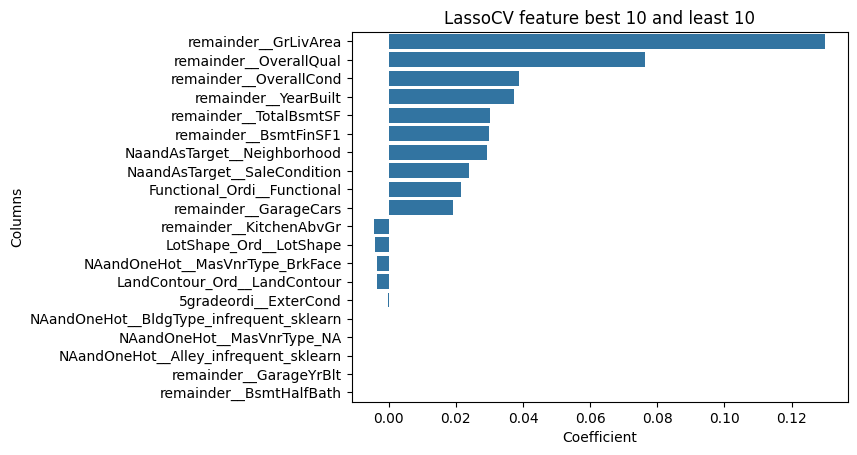

In [189]:
# 繪製水平長條圖畫出最好的 10 項與最不好的 10 項
lassoCV_barchart_20cols_df =pd.concat([LassoCV_Coefdf[LassoCV_Coefdf['Coefficient']>0].head(10),LassoCV_Coefdf.sort_values(by='Coefficient', ascending= True).head(10)],axis=0)

sns.barplot(x=lassoCV_barchart_20cols_df['Coefficient'],y = lassoCV_barchart_20cols_df['Columns'])
plt.title('LassoCV feature best 10 and least 10')
plt.xlabel('Coefficient')
plt.ylabel('Columns')

In [190]:
# 查看標準化之前的轉碼，前 10 名的 one hot + ordinal 標準化僅有 functional 一欄位。
std_check_cols = ['OverallQual','OverallCond','Functional','GarageCars']
numeric_cols = ['GrLivArea','TotalBsmtSF','BsmtFinSF1']


In [191]:
# 找出目標欄位中的特徵係數除以標準差，求得原本的數值
for t in std_check_cols:
    row = LassoCV_Coefdf[LassoCV_Coefdf['Columns'].str.contains(t,regex=False)].iloc[0] # 欄位名稱已經有改過所以要抓出包含目標名稱的欄位
    std_dev = row['Std_Dev']
    scaled_coef = row['Coefficient']
    real_coef = scaled_coef/std_dev
    premium_percent = (np.exp(real_coef)-1)

    print(f"{t} 的標準化反向拆解：")
    print(f"LassoCV 標準化後壓縮之特徵係數為：{scaled_coef:.5f} ")
    print(f"真實特徵係數為：{real_coef:.5f} ")
    print(f"溢價百分比為：{premium_percent*100:.4f}% ")
    print(f"若房價為 20 萬美元，則提升一單位可以增加：{premium_percent*200000:.2f} 美金 ")
    print(f"  ")


OverallQual 的標準化反向拆解：
LassoCV 標準化後壓縮之特徵係數為：0.07624 
真實特徵係數為：0.05611 
溢價百分比為：5.7713% 
若房價為 20 萬美元，則提升一單位可以增加：11542.54 美金 
  
OverallCond 的標準化反向拆解：
LassoCV 標準化後壓縮之特徵係數為：0.03892 
真實特徵係數為：0.03486 
溢價百分比為：3.5478% 
若房價為 20 萬美元，則提升一單位可以增加：7095.68 美金 
  
Functional 的標準化反向拆解：
LassoCV 標準化後壓縮之特徵係數為：0.02151 
真實特徵係數為：0.03249 
溢價百分比為：3.3025% 
若房價為 20 萬美元，則提升一單位可以增加：6605.09 美金 
  
GarageCars 的標準化反向拆解：
LassoCV 標準化後壓縮之特徵係數為：0.01903 
真實特徵係數為：0.02573 
溢價百分比為：2.6066% 
若房價為 20 萬美元，則提升一單位可以增加：5213.30 美金 
  


In [192]:
# 找出目標欄位中的特徵係數，換算溢價百分比
for t in numeric_cols:
    row = LassoCV_Coefdf[LassoCV_Coefdf['Columns'].str.contains(t,regex=False)].iloc[0] # 欄位名稱已經有改過所以要抓出包含目標名稱的欄位
    std_dev = row['Std_Dev']
    real_coef  = row['Coefficient']
    premium_percent = (np.exp(real_coef)-1)

    print(f"{t} 的特徵係數拆解：")
    print(f"真實特徵係數為：{real_coef:.5f} ")
    print(f"標準差為：{std_dev:.5f} ")
    print(f"溢價百分比為：{premium_percent*100:.4f}% ")
    print(f"每提升 {std_dev:.5f} 就有機會提高 {premium_percent:.4f}%  的房價。")
    print(f"若房價為 20 萬美元，則提升一單位可以增加：{premium_percent*200000:.2f} 美金 ")
    print(f"  ")


GrLivArea 的特徵係數拆解：
真實特徵係數為：0.13001 
標準差為：502.19993 
溢價百分比為：13.8841% 
每提升 502.19993 就有機會提高 0.1388%  的房價。
若房價為 20 萬美元，則提升一單位可以增加：27768.16 美金 
  
TotalBsmtSF 的特徵係數拆解：
真實特徵係數為：0.03026 
標準差為：410.81794 
溢價百分比為：3.0719% 
每提升 410.81794 就有機會提高 0.0307%  的房價。
若房價為 20 萬美元，則提升一單位可以增加：6143.87 美金 
  
BsmtFinSF1 的特徵係數拆解：
真實特徵係數為：0.02999 
標準差為：429.99575 
溢價百分比為：3.0449% 
每提升 429.99575 就有機會提高 0.0304%  的房價。
若房價為 20 萬美元，則提升一單位可以增加：6089.86 美金 
  


In [193]:
# neighborhood, salecondition 取出平滑化之數字查看
LassoCV_targetEncoder_map = LassoCVModel.named_steps['dataclean'].named_steps['colTrans'].named_transformers_['NaandAsTarget'].named_steps['astarget']
targetCols = ['Neighborhood','SaleCondition']

Category_word_map = LassoCV_targetEncoder_map.ordinal_encoder.mapping

for item in LassoCV_targetEncoder_map.mapping:
    for t in targetCols:
        row = LassoCV_Coefdf[LassoCV_Coefdf['Columns'].str.contains(t,regex=False)].iloc[0] # 欄位名稱已經有改過所以要抓出包含目標名稱的欄位
        std_dev = row['Std_Dev']
        real_coef  = row['Coefficient']
        for encodeitem in Category_word_map:
            if item == t and encodeitem['col'] ==  t:
                id_to_scores = LassoCV_targetEncoder_map.mapping[item].sort_values(ascending = False)
                encode_to_id = encodeitem['mapping']
                fullmap = encode_to_id.map(id_to_scores)
                p_fullmap = fullmap.dropna().sort_values(ascending=False).drop(fullmap[fullmap.index.isnull()].index,axis=0)
                topx= fullmap.dropna().sort_values(ascending=False).drop(fullmap[fullmap.index.isnull()].index,axis=0).idxmax()
                top_log = fullmap.loc[topx]

                bottomx= fullmap.dropna().sort_values(ascending=False).drop(fullmap[fullmap.index.isnull()].index,axis=0).idxmin()
                bottom_log = fullmap.loc[bottomx]

                print (f"{item} 的特徵係數 {real_coef:.5f}與標準差{std_dev:.5f}")
                print(f"{item} 的最高分類為 {topx}，其平均 log 為:{top_log:.2f}")
                print(f"{item} 的最低分類為 {bottomx}，其平均 log 為:{bottom_log:.2f}")
                delta = (top_log -bottom_log )*real_coef
                delta_premium = np.exp(delta)-1
                amount = 200000 * delta_premium

                print(f"{item} 的最高與最低分類之溢價百分比差距為：{delta_premium*100:.2f}％")
                print(f"相對 20 萬美元房價差異 {amount:.2f} 美元")
                print ("")

                print(f"{item} 的 Target Encoder 分數排行：")
                print(p_fullmap)
                print ("")


                break

Neighborhood 的特徵係數 0.02932與標準差0.25159
Neighborhood 的最高分類為 NridgHt，其平均 log 為:12.60
Neighborhood 的最低分類為 BrkSide，其平均 log 為:11.69
Neighborhood 的最高與最低分類之溢價百分比差距為：2.69％
相對 20 萬美元房價差異 5381.71 美元

Neighborhood 的 Target Encoder 分數排行：
NridgHt    12.598144
NoRidge    12.511846
StoneBr    12.298364
Somerst    12.295955
Timber     12.243266
Crawfor    12.194194
CollgCr    12.179074
Gilbert    12.172822
ClearCr    12.153441
NWAmes     12.131411
Veenker    12.122774
Blmngtn    12.076647
SawyerW    12.053066
NPkVill    11.998088
Blueste    11.991250
Mitchel    11.953991
SWISU      11.936305
MeadowV    11.889477
NAmes      11.877954
BrDale     11.859161
Sawyer     11.814239
OldTown    11.734711
IDOTRR     11.705573
Edwards    11.704499
BrkSide    11.692421
dtype: float64

SaleCondition 的特徵係數 0.02400與標準差0.13247
SaleCondition 的最高分類為 Partial，其平均 log 為:12.45
SaleCondition 的最低分類為 Abnorml，其平均 log 為:11.83
SaleCondition 的最高與最低分類之溢價百分比差距為：1.50％
相對 20 萬美元房價差異 3003.79 美元

SaleCondition 的 Target Encoder 分數排行：
Part

In [194]:
# shap
import shap

In [195]:
dataprocesspipe_only = LassoCVModel[:-1]
X_trainML_large_array = dataprocesspipe_only.transform(X_trainML_large)
x_test_ML_array= dataprocesspipe_only.transform(x_test_ML)

In [196]:
x_tr_clean_df = pd.DataFrame(X_trainML_large_array,columns = CVFeaturelist)
x_test_clean_df = pd.DataFrame(x_test_ML_array,columns = CVFeaturelist)

In [197]:
# 進入 shap 先讓他抓平均基準線
shap_sample_data = shap.sample(x_tr_clean_df,100)
Shap_Explainer = shap.LinearExplainer(LassoCVModel[-1],shap_sample_data)

In [198]:
target_house = x_test_clean_df.loc[[588]]
target_house[['remainder__OverallCond','NaandAsTarget__SaleCondition','remainder__BsmtFinSF1']]

,remainder__OverallCond,NaandAsTarget__SaleCondition,remainder__BsmtFinSF1
588,2.162757,3.132849,2.05581


In [199]:
x_test_ML.loc[[588]][['OverallCond','SaleCondition','BsmtFinSF1']]

,OverallCond,SaleCondition,BsmtFinSF1
588,8,Partial,1324


In [200]:
target_house_shapV = Shap_Explainer(target_house)

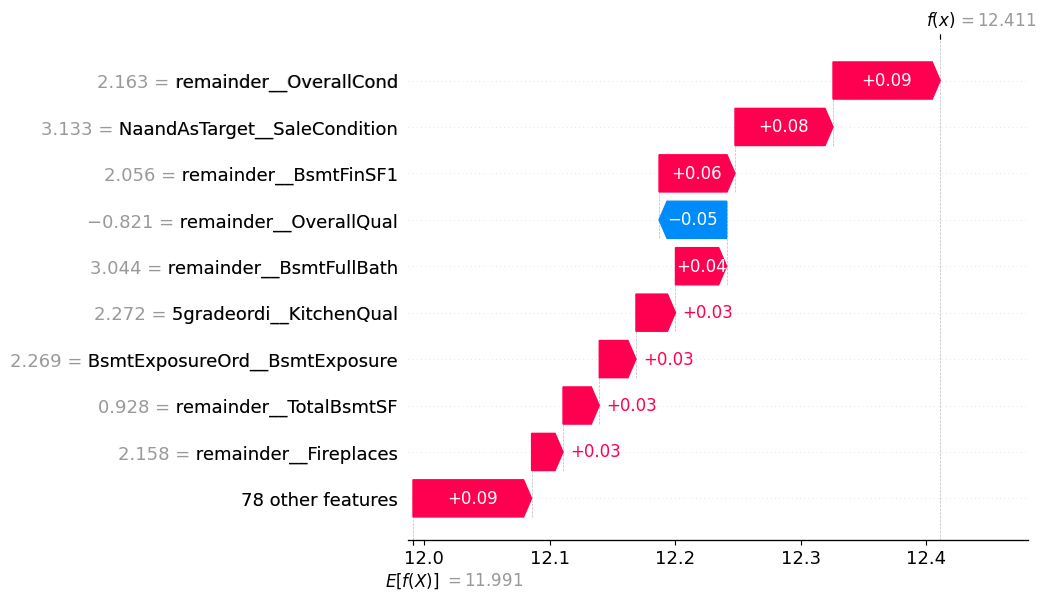

In [201]:
shap.plots.waterfall(target_house_shapV[0],max_display = 10)


### 將 LassoCV 結果上傳 Kaggle

In [202]:
kaggletestdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [203]:
missingdf = preprocessor.transform(kaggletestdf)
missingdf.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 87 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   NAandOneHot__Alley_NA                        1459 non-null   float64
 1   NAandOneHot__Alley_infrequent_sklearn        1459 non-null   float64
 2   NAandOneHot__MasVnrType_BrkFace              1459 non-null   float64
 3   NAandOneHot__MasVnrType_NA                   1459 non-null   float64
 4   NAandOneHot__MasVnrType_infrequent_sklearn   1459 non-null   float64
 5   NAandOneHot__MiscFeature_NA                  1459 non-null   float64
 6   NAandOneHot__MiscFeature_infrequent_sklearn  1459 non-null   float64
 7   NAandOneHot__Street_Pave                     1459 non-null   float64
 8   NAandOneHot__Street_infrequent_sklearn       1459 non-null   float64
 9   NAandOneHot__MSZoning_RL                     1459 non-null   float64
 10  

In [204]:
# 調查缺失值欄位與數量
null_kaggletestdata = missingdf.isnull().sum()
null_kgcolumns = null_kaggletestdata[null_kaggletestdata > 0].sort_values( ascending = True)
print(null_kgcolumns)

Series([], dtype: int64)


In [205]:
LassoCV_prediction_log = LassoCVModel.predict(kaggletestdf)
LassoCV_prediction_Saleprice = np.expm1(LassoCV_prediction_log)

In [206]:
# 轉成 kaggle 指定提交檔案類型
logy_testMLsubmitPriceLassoCV = pd.DataFrame({"Id":kaggletestdf['Id'],'SalePrice':LassoCV_prediction_Saleprice })

logy_testMLsubmitPriceLassoCV.to_csv('submission_2.csv', index=False)